In [1]:
# file: scripts/lgbm_from_feature_csvs.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, adjusted_rand_score, v_measure_score
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
FILES = {
    "HVG-Harmony":           "features_hvg_harmony.csv",
    "Markers-Harmony":       "features_markers_harmony.csv",
    "Combined (raw concat)": "features_combined.csv",
    "Combined (z-score)":    "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
N_SPLITS  = 5
SEED      = 42
LGB_PARAMS = dict(
    objective="multiclass",
    learning_rate=0.02,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,             # with early stopping
    subsample=0.6,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
EARLY_STOP_ROUNDS = 50

# ---------------- Utils ----------------
def load_features(path: str, label_col: str = LABEL_COL) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """Load cells×features CSV. y from label_col; X = all numeric cols (including pct_counts_mt & embeddings)."""
    df = pd.read_csv(path, index_col=0)
    if label_col not in df.columns:
        raise ValueError(f"{os.path.basename(path)} 缺少標籤欄位 '{label_col}'")
    y_str = df[label_col].astype(str).values

    # keep only numeric columns for features
    num_df = df.select_dtypes(include=[np.number]).copy()

    # drop columns with all NaN or zero variance
    nunique = num_df.nunique(dropna=True)
    keep = (nunique > 1)
    X_df = num_df.loc[:, keep]
    dropped = num_df.columns[~keep].tolist()

    # LightGBM 可處理 NaN；這裡不強制填補，但若全列都是 NaN 會在前面被丟
    X = X_df.to_numpy(dtype=float)
    feature_names = X_df.columns.tolist()

    if X.shape[1] == 0:
        raise ValueError(f"{os.path.basename(path)} 沒有可用的數值特徵（可能都為常數或缺失）。")

    if dropped:
        print(f"[Info] {os.path.basename(path)} 移除 {len(dropped)} 個常數特徵。")

    return X, y_str, feature_names

def cv_eval_lgbm(X: np.ndarray, y_str: np.ndarray) -> pd.DataFrame:
    """5-fold stratified CV with early stopping. Return per-fold and mean metrics."""
    le = LabelEncoder().fit(y_str)
    y = le.transform(y_str)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        clf = lgb.LGBMClassifier(num_class=len(le.classes_), **LGB_PARAMS)
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it = clf.best_iteration_ or LGB_PARAMS["n_estimators"]
        y_hat = clf.predict(X_va, num_iteration=best_it)

        acc = accuracy_score(y_va, y_hat)
        f1m = f1_score(y_va, y_hat, average="macro")
        ari = adjusted_rand_score(y_va, y_hat)
        vme = v_measure_score(y_va, y_hat)
        sc  = 0.5 * (ari + vme)

        rows.append({
            "fold": fold,
            "n_train": int(len(tr_idx)),
            "n_val": int(len(va_idx)),
            "best_iter": int(best_it),
            "ACC": float(acc),
            "F1_macro": float(f1m),
            "ARI": float(ari),
            "V": float(vme),
            "Score(0.5*ARI+0.5*V)": float(sc),
        })

    df = pd.DataFrame(rows)
    df.loc["mean"] = {
        "fold": "mean",
        "n_train": int(np.mean(df["n_train"])),
        "n_val": int(np.mean(df["n_val"])),
        "best_iter": int(np.round(df["best_iter"].mean())),
        "ACC": df["ACC"].mean(),
        "F1_macro": df["F1_macro"].mean(),
        "ARI": df["ARI"].mean(),
        "V": df["V"].mean(),
        "Score(0.5*ARI+0.5*V)": df["Score(0.5*ARI+0.5*V)"].mean(),
    }
    return df

# ---------------- Run for each file ----------------
available: Dict[str, str] = {}
for name, fname in FILES.items():
    path = os.path.join(IN_DIR, fname)
    if os.path.exists(path):
        available[name] = path

if not available:
    raise FileNotFoundError(f"找不到任何特徵檔於 {IN_DIR}：{list(FILES.values())}")

summary_rows = []
for name, path in available.items():
    print(f"\n=== LGBM CV on: {name} ===")
    X, y_str, feat_names = load_features(path)
    print(f"Loaded: {os.path.basename(path)} | X={X.shape} | classes={len(np.unique(y_str))} | features={len(feat_names)}")
    df = cv_eval_lgbm(X, y_str)
    print(df.to_string(index=False))

    # keep means for summary
    mean_row = df.loc["mean"]
    summary_rows.append({
        "FeatureSet": name,
        "ACC": mean_row["ACC"],
        "F1_macro": mean_row["F1_macro"],
        "ARI": mean_row["ARI"],
        "V": mean_row["V"],
        "Score": mean_row["Score(0.5*ARI+0.5*V)"],
        "best_iter_mean": int(mean_row["best_iter"]),
        "n_val_mean": int(mean_row["n_val"]),
    })

# Summary across sets
summary = pd.DataFrame(summary_rows).sort_values("Score", ascending=False)
print("\n=== Summary (sorted by Score=0.5*ARI+0.5*V) ===")
print(summary.to_string(index=False))



=== LGBM CV on: HVG-Harmony ===


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\2828703065.py:39: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


Loaded: features_hvg_harmony.csv | X=(50990, 51) | classes=10 | features=51
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13005
[LightGBM] [Info] Number of data points in the train set: 40792, number of used features: 51
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.487951
[LightGBM] [Info] Start training from score -4.444541
[LightGBM] [Info] Start training from score -2.975637
[LightGBM] [Info] Start training from score -3.825020
[LightGBM] [Info] Start training from score -3.02035

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010026 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13005
[LightGBM] [Info] Number of data points in the train set: 40792, number of used features: 51
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.488246
[LightGBM] [Info] Start training from score -4.444541
[LightGBM] [Info] Start training from score -2.975157
[LightGBM] [Info] Start training from score -3.826144
[Light

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022972 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 40792, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.487951
[LightGBM] [Info] Start training from score -4.444541
[LightGBM] [Info] Start training from score -2.975157
[LightGBM] [Info] Start training from score -3.825020
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 40792, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.487951
[LightGBM] [Info] Start training from score -4.442455
[LightGBM] [Info] Start training from score -2.975637
[LightGBM] [Info] Start training from score -3.825020
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
fold  n_train  n_val  best_iter      ACC  F1_macro      ARI        V  Score(0.5*ARI+0.5*V)
   1    40792  10198        412 0.849382  0.776570 0.637354 0.667417              0.652386
   2    40792  10198        408 0.850167  0.772569 0.640351 0.664319              0.652335
   3    40792  10198        450 0.850265  0.789256 0.634961 0.669207              0.652084
   4    40792  10198        419 0.857129  0.783986 0.651845 0.677809              0.664827
   5    40792  10198        401 0.845754  0.777945 0.622224 0.666385              0.644304
mean    40792  10198        418 0.850539  0.780065 0.637347 0.669027              0.653187

=== Summary (sorted by Score=0.5*ARI+0.5*V) ===
           FeatureSet      ACC  F1_macro      ARI        V    Score  best_iter_mean  n_val_mean
Combined (raw concat) 0.851049  0.777999 0.639573 0.669253 0.654413             433       10198


In [7]:
# --- Inspect percentage of cell_type in features_combined_z-score.csv ---
import os
import pandas as pd
import numpy as np

IN_DIR = "./outputs_features_csv"
FNAME  = "features_combined_z-score.csv"
PATH   = os.path.join(IN_DIR, FNAME)

if not os.path.exists(PATH):
    raise FileNotFoundError(f"Not found: {PATH}")

df = pd.read_csv(PATH, index_col=0)

if "cell_type" not in df.columns:
    raise ValueError(f"Column 'cell_type' not found in {FNAME}. Available: {list(df.columns)[:12]}...")

# clean label strings to avoid 'nan' text
ct = df["cell_type"].astype(str).str.strip()
ct = ct.mask(ct.str.lower().isin(["", "nan"]), np.nan)  # treat '' and 'nan' as missing

def as_percent_series(s: pd.Series) -> pd.Series:
    """why: show percent instead of count; drop NaN before computing."""
    s = s.dropna()
    return (s.value_counts(normalize=True).sort_index() * 100.0).round(2)

# Overall percentages
pct_overall = as_percent_series(ct)
print("=== Percentage of cell_type (overall, %) ===")
print(pct_overall.to_string())

# If 'set' exists, also split by train/test and show percentages
if "set" in df.columns:
    sets = df["set"].astype(str).unique().tolist()
    for s in sorted(sets):
        mask = df["set"].astype(str) == s
        pct_s = as_percent_series(ct[mask])
        print(f"\n=== Percentage of cell_type in set='{s}' (%, within-set) ===")
        if pct_s.empty:
            print("[no labeled rows]")
        else:
            print(pct_s.to_string())
else:
    print("\n[Info] Column 'set' not found; only overall percentages printed.")


=== Percentage of cell_type (overall, %) ===
cell_type
B                13.08
Endothelial       1.85
Fibroblast        8.04
Mast              3.43
Myeloid           7.68
Myofibroblast     2.22
NK                5.90
Plasmablast       6.28
T                51.51

[Info] Column 'set' not found; only overall percentages printed.


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\2991244496.py:13: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH, index_col=0)


In [6]:
# file: scripts/lgbm_from_feature_csvs_imbalanced.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
FILES = {
    "Combined (raw concat)": "features_combined.csv",
    "Combined (z-score)":    "features_combined_z-score.csv",

}
LABEL_COL = "cell_type"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]  # 依序嘗試
N_SPLITS  = 5
SEED      = 42

# 不平衡處理參數
USE_SAMPLE_WEIGHTS = True         # why: 依類別頻率做反比加權
WEIGHT_SMOOTH_ALPHA = 0.0         # >0 可平滑：count+alpha
WEIGHT_MAX = 5.0                  # 限制極端權重；None 表示不裁切

# ---------------- Utils ----------------
def load_features(path: str, label_col: str = LABEL_COL,
                  optional_group_cols: List[str] = OPTIONAL_GROUP_COLS
                 ) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], List[str]]:
    df = pd.read_csv(path, index_col=0)

    if label_col not in df.columns:
        raise ValueError(f"{os.path.basename(path)} 缺少標籤欄位 '{label_col}'")

    # ---- 先濾掉沒有 label 的列（通常是 test rows）----
    lbl = df[label_col]
    valid_mask = (
        lbl.notna()
        & lbl.astype(str).str.strip().ne("")           # 空字串
        & lbl.astype(str).str.lower().ne("nan")        # 文字 'nan'
    )
    n_before, n_after = len(df), int(valid_mask.sum())
    if n_after == 0:
        raise ValueError(f"{os.path.basename(path)} 內沒有任何帶標籤的資料列。")
    if n_after < n_before:
        print(f"[Info] {os.path.basename(path)} 移除無標籤列（可能為 test）：{n_before - n_after} / {n_before}")

    df = df.loc[valid_mask].copy()

    # groups: 盡量用 Patient，其次 Sample，再不行用 set；若都沒有，返回 None
    group = None
    for c in optional_group_cols:
        if c in df.columns:
            group = df[c].astype(str).values
            break

    y_str = df[label_col].astype(str).values

    # features = 所有數值欄（含 pct_counts_mt 與 embeddings）
    X_df = df.select_dtypes(include=[np.number]).copy()

    # 丟掉全 NaN 或常數欄
    nunique = X_df.nunique(dropna=True)
    keep = (nunique > 1)
    if keep.sum() == 0:
        raise ValueError(f"{os.path.basename(path)} 沒有可用的數值特徵（全為常數或缺失）。")
    X_df = X_df.loc[:, keep]

    X = X_df.to_numpy(dtype=float)
    feat_names = X_df.columns.tolist()
    return X, y_str, group, feat_names


def make_sample_weights(y_str: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    """why: 反比於類別頻率，防止少數類別被忽略。"""
    vc = pd.Series(y_str).value_counts()
    K = float(vc.shape[0])
    N = float(len(y_str))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_str], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def cv_eval_lgbm(X: np.ndarray, y_str: np.ndarray, groups: Optional[np.ndarray]) -> pd.DataFrame:
    le = LabelEncoder().fit(y_str)
    y = le.transform(y_str)

    # splitter
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X, y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(X, y)

    rows = []
    sw_all = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y, dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        sw_tr = sw_all[tr_idx] if USE_SAMPLE_WEIGHTS else None

        clf = lgb.LGBMClassifier(num_class=len(le.classes_), **LGB_PARAMS)
        clf.fit(
            X_tr, y_tr,
            sample_weight=sw_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it = clf.best_iteration_ or LGB_PARAMS["n_estimators"]
        y_hat = clf.predict(X_va, num_iteration=best_it)

        acc  = accuracy_score(y_va, y_hat)
        bacc = balanced_accuracy_score(y_va, y_hat)
        f1m  = f1_score(y_va, y_hat, average="macro")
        ari  = adjusted_rand_score(y_va, y_hat)
        vme  = v_measure_score(y_va, y_hat)
        score= 0.5 * (ari + vme)

        rows.append({
            "fold": fold,
            "n_train": int(len(tr_idx)),
            "n_val": int(len(va_idx)),
            "best_iter": int(best_it),
            "ACC": float(acc),
            "Balanced_ACC": float(bacc),
            "F1_macro": float(f1m),
            "ARI": float(ari),
            "V": float(vme),
            "Score(0.5*ARI+0.5*V)": float(score),
        })

    df = pd.DataFrame(rows)
    df.loc["mean"] = {
        "fold": "mean",
        "n_train": int(np.mean(df["n_train"])),
        "n_val": int(np.mean(df["n_val"])),
        "best_iter": int(np.round(df["best_iter"].mean())),
        "ACC": df["ACC"].mean(),
        "Balanced_ACC": df["Balanced_ACC"].mean(),
        "F1_macro": df["F1_macro"].mean(),
        "ARI": df["ARI"].mean(),
        "V": df["V"].mean(),
        "Score(0.5*ARI+0.5*V)": df["Score(0.5*ARI+0.5*V)"].mean(),
    }
    return df

# ---------------- Run for each feature file ----------------
available: Dict[str, str] = {}
for name, fname in FILES.items():
    path = os.path.join(IN_DIR, fname)
    if os.path.exists(path):
        available[name] = path

if not available:
    raise FileNotFoundError(f"找不到任何特徵檔於 {IN_DIR}：{list(FILES.values())}")

summary_rows = []
for name, path in available.items():
    print(f"\n=== LGBM CV on: {name} ===")
    X, y_str, groups, feat_names = load_features(path)
    print(f"Loaded: {os.path.basename(path)} | X={X.shape} | classes={len(np.unique(y_str))} | features={len(feat_names)}"
          + (f" | groups={groups.dtype.name}" if groups is not None else " | groups=None"))
    df = cv_eval_lgbm(X, y_str, groups)
    print(df.to_string(index=False))

    mean_row = df.loc["mean"]
    summary_rows.append({
        "FeatureSet": name,
        "ACC": mean_row["ACC"],
        "Balanced_ACC": mean_row["Balanced_ACC"],
        "F1_macro": mean_row["F1_macro"],
        "ARI": mean_row["ARI"],
        "V": mean_row["V"],
        "Score": mean_row["Score(0.5*ARI+0.5*V)"],
        "best_iter_mean": int(mean_row["best_iter"]),
    })

summary = pd.DataFrame(summary_rows).sort_values("Score", ascending=False)
print("\n=== Summary (sorted by Score=0.5*ARI+0.5*V) ===")
print(summary.to_string(index=False))



=== LGBM CV on: Combined (raw concat) ===


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\3382140004.py:36: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[Info] features_combined.csv 移除無標籤列（可能為 test）：18616 / 50990
Loaded: features_combined.csv | X=(32374, 101) | classes=9 | features=101 | groups=None
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011009 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -2.362116
[LightGBM] [Info] Start training from score -2.178800
[LightGBM] [Info] Start training 

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178528
[LightGBM] [Info] Start training from score -2.361896
[LightGBM] [Info] Start training from score -2.178099
[LightGBM] [Info] Start training from score -2.178966
[Ligh

...

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178267
[LightGBM] [Info] Start training from score -2.361930
[LightGBM] [Info] Start training from score -2.178134
[LightGBM] [Info] Start training from score -2.177876
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
# file: scripts/lgbm_two_stage_mask_vs_unmask.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
FILES = {
    "Combined (raw concat)": "features_combined.csv",
    "Combined (z-score)":    "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]
N_SPLITS  = 5
SEED      = 42

# LightGBM
EARLY_STOP_ROUNDS = 50  # <= updated
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance controls
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# Threshold grid: 0.1 ~ 0.9 step 0.1  <= updated
THRESH_GRID = np.arange(0.1, 1.0, 0.1)

# ---------------- Utils ----------------
def load_features(path: str, label_col: str = LABEL_COL,
                  optional_group_cols: List[str] = OPTIONAL_GROUP_COLS
                 ) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], List[str]]:
    df = pd.read_csv(path, index_col=0)
    if label_col not in df.columns:
        raise ValueError(f"{os.path.basename(path)} 缺少標籤欄位 '{label_col}'")
    lbl = df[label_col]
    valid_mask = lbl.notna() & lbl.astype(str).str.strip().ne("") & lbl.astype(str).str.lower().ne("nan")
    if valid_mask.sum() == 0:
        raise ValueError(f"{os.path.basename(path)} 內沒有任何帶標籤的資料列。")
    if valid_mask.sum() < len(df):
        print(f"[Info] {os.path.basename(path)} 移除無標籤列：{len(df) - int(valid_mask.sum())} / {len(df)}")
    df = df.loc[valid_mask].copy()

    group = None
    for c in optional_group_cols:
        if c in df.columns:
            group = df[c].astype(str).values
            break

    y_str = df[label_col].astype(str).values
    X_df = df.select_dtypes(include=[np.number]).copy()
    nunique = X_df.nunique(dropna=True)
    keep = (nunique > 1)
    if keep.sum() == 0:
        raise ValueError(f"{os.path.basename(path)} 沒有可用的數值特徵。")
    X_df = X_df.loc[:, keep]

    X = X_df.to_numpy(dtype=float)
    feat_names = X_df.columns.tolist()
    return X, y_str, group, feat_names

def make_sample_weights(y_str: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    vc = pd.Series(y_str).value_counts()
    K = float(vc.shape[0]); N = float(len(y_str))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_str], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

def pick_best_threshold(p_pos: np.ndarray, y_true_bin: np.ndarray, grid: np.ndarray) -> Tuple[float, float]:
    best_thr, best_acc = 0.5, -1.0
    for t in grid:
        pred = (p_pos >= t).astype(int)
        acc = accuracy_score(y_true_bin, pred)
        if acc > best_acc:
            best_acc, best_thr = acc, t
    return float(best_thr), float(best_acc)

def run_two_stage_cv(X: np.ndarray, y_str: np.ndarray, groups: Optional[np.ndarray]) -> pd.DataFrame:
    le_full = LabelEncoder().fit(y_str)
    y_multi = le_full.transform(y_str)
    y_bin = (y_str == POS_LABEL).astype(int)

    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X, y_multi, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(X, y_multi)

    sw_multi = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y_multi, dtype=float)
    sw_bin   = make_sample_weights(np.where(y_bin==1, POS_LABEL, "nonT")) if USE_SAMPLE_WEIGHTS else np.ones_like(y_bin, dtype=float)

    rows = []
    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X[tr_idx], X[va_idx]
        y_tr_multi, y_va_multi = y_multi[tr_idx], y_multi[va_idx]
        y_tr_bin,   y_va_bin   = y_bin[tr_idx],   y_bin[va_idx]
        sw_tr_multi = sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None
        sw_tr_bin   = sw_bin[tr_idx]   if USE_SAMPLE_WEIGHTS else None

        # Stage-1: Binary
        bin_clf = lgb.LGBMClassifier(**{**LGB_PARAMS_BIN})
        bin_clf.fit(
            X_tr, y_tr_bin,
            sample_weight=sw_tr_bin,
            eval_set=[(X_va, y_va_bin)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
        p_pos = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
        thr_star, acc_bin = pick_best_threshold(p_pos, y_va_bin, THRESH_GRID)

        # Stage-2: Multiclass
        K = len(le_full.classes_)
        multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        multi_clf.fit(
            X_tr, y_tr_multi,
            sample_weight=sw_tr_multi,
            eval_set=[(X_va, y_va_multi)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]

        # baseline
        yhat_multi = multi_clf.predict(X_va, num_iteration=best_it_multi)

        # masked
        mask_is_T = (p_pos >= thr_star)
        yhat_mask = yhat_multi.copy()
        if POS_LABEL in le_full.classes_:
            t_idx = int(np.where(le_full.classes_ == POS_LABEL)[0][0])
            yhat_mask[mask_is_T] = t_idx

        m_base = metrics_all(y_va_multi, yhat_multi)
        m_mask = metrics_all(y_va_multi, yhat_mask)

        rows.append({
            "fold": fold,
            "val_n": int(len(va_idx)),
            "thr_star": float(thr_star),
            "bin_ACC_at_thr": float(acc_bin),
            "base_ACC": m_base["ACC"],
            "base_BalACC": m_base["Balanced_ACC"],
            "base_F1m": m_base["F1_macro"],
            "base_ARI": m_base["ARI"],
            "base_V":   m_base["V"],
            "base_Score": 0.5*(m_base["ARI"] + m_base["V"]),
            "mask_ACC": m_mask["ACC"],
            "mask_BalACC": m_mask["Balanced_ACC"],
            "mask_F1m": m_mask["F1_macro"],
            "mask_ARI": m_mask["ARI"],
            "mask_V":   m_mask["V"],
            "mask_Score": 0.5*(m_mask["ARI"] + m_mask["V"]),
            "delta_Score": 0.5*(m_mask["ARI"] + m_mask["V"]) - 0.5*(m_base["ARI"] + m_base["V"]),
            "best_iter_bin": int(best_it_bin),
            "best_iter_multi": int(best_it_multi),
        })

    df = pd.DataFrame(rows)
    mean_row = {
        "fold": "mean",
        "val_n": int(np.mean(df["val_n"])),
        "thr_star": float(np.mean(df["thr_star"])),
        "bin_ACC_at_thr": float(np.mean(df["bin_ACC_at_thr"])),
        "base_ACC": float(np.mean(df["base_ACC"])),
        "base_BalACC": float(np.mean(df["base_BalACC"])),
        "base_F1m": float(np.mean(df["base_F1m"])),
        "base_ARI": float(np.mean(df["base_ARI"])),
        "base_V":   float(np.mean(df["base_V"])),
        "base_Score": float(np.mean(df["base_Score"])),
        "mask_ACC": float(np.mean(df["mask_ACC"])),
        "mask_BalACC": float(np.mean(df["mask_BalACC"])),
        "mask_F1m": float(np.mean(df["mask_F1m"])),
        "mask_ARI": float(np.mean(df["mask_ARI"])),
        "mask_V":   float(np.mean(df["mask_V"])),
        "mask_Score": float(np.mean(df["mask_Score"])),
        "delta_Score": float(np.mean(df["delta_Score"])),
        "best_iter_bin": int(np.round(np.mean(df["best_iter_bin"]))),
        "best_iter_multi": int(np.round(np.mean(df["best_iter_multi"]))),
    }
    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
    return df

# ---------------- Run ----------------
available: Dict[str, str] = {}
for name, fname in FILES.items():
    path = os.path.join(IN_DIR, fname)
    if os.path.exists(path):
        available[name] = path

if not available:
    raise FileNotFoundError(f"找不到任何特徵檔於 {IN_DIR}：{list(FILES.values())}")

for name, path in available.items():
    print(f"\n=== Two-Stage CV on: {name} ===")
    X, y_str, groups, feat_names = load_features(path)
    print(f"Loaded: {os.path.basename(path)} | X={X.shape} | classes={len(np.unique(y_str))} | features={len(feat_names)}"
          + (f" | groups={groups.dtype.name}" if groups is not None else " | groups=None"))

    df = run_two_stage_cv(X, y_str, groups)
    print(df.to_string(index=False))

    last = df.iloc[-1]
    print("\n[Mean]")
    print(pd.DataFrame({
        "binary_thr*":[last["thr_star"]],
        "binary_ACC@thr*":[last["bin_ACC_at_thr"]],
        "UNMASK_Score":[last["base_Score"]],
        "MASK_Score":[last["mask_Score"]],
        "ΔScore":[last["delta_Score"]],
        "UNMASK_ARI":[last["base_ARI"]],
        "MASK_ARI":[last["mask_ARI"]],
        "UNMASK_V":[last["base_V"]],
        "MASK_V":[last["mask_V"]],
    }).round(4).to_string(index=False))



=== Two-Stage CV on: Combined (raw concat) ===


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\2121865412.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[Info] features_combined.csv 移除無標籤列：18616 / 50990
Loaded: features_combined.csv | X=(32374, 101) | classes=9 | features=101 | groups=None
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007469 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007476 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -2.362116
[LightGBM] [Info] Start training from score -2.178800
[LightGBM] [Info] Start training from score -2.178062
[Ligh

...

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007495 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499992 -> initscore=-0.000033
[LightGBM] [Info] Start training from score -0.000033


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007931 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# file: scripts/lgbm_two_stage_kfold_fixedthr_predict_test.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
OUT_DIR = "./outputs_features_csv"
FILES = {
    "Combined (z-score)":    "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]
N_SPLITS  = 5
SEED      = 42

# 固定門檻
FIXED_THRESHOLD = 0.55

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance：樣本權重（不改分布）
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df

def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        # 全部皆視為未標籤
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)

def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None

def make_sample_weights(y_like: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    vc = pd.Series(y_like).value_counts()
    K = float(vc.shape[0]); N = float(len(y_like))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_like], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def ensure_prob_matrix(proba, K: int) -> np.ndarray:
    if isinstance(proba, list):
        proba = np.column_stack(proba)
    proba = np.asarray(proba, dtype=float)
    if proba.ndim == 1:
        proba = proba.reshape(-1, 1)
    if proba.shape[1] != K:
        # 部分 LGB 版本在二元時回傳 (n, ) 為正類；這裡不會用到（多類用 K）
        pass
    return proba

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

# ---------------- Per-file run ----------------
def run_kfold_and_predict(df: pd.DataFrame, fname: str) -> None:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows for training.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_str_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    # labeled / unlabeled split for training & predicting
    X_lab = X_all[is_lab.values]
    y_str = y_str_all[is_lab.values]
    idx_lab = idx_all[is_lab.values]

    X_unlab = X_all[is_unlab.values]
    idx_unlab = idx_all[is_unlab.values]

    # encoders & constants
    le = LabelEncoder().fit(y_str)
    classes = le.classes_
    if POS_LABEL not in classes:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not in labels {classes.tolist()}")
    idx_T = int(np.where(classes == POS_LABEL)[0][0])
    y = le.transform(y_str)
    y_bin = (y_str == POS_LABEL).astype(int)
    K = len(classes)

    # groups (only for labeled)
    groups = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)

    # split
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X_lab, y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(X_lab, y)

    # weights
    sw_multi = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y, dtype=float)
    yb_lbl = np.where(y_bin==1, POS_LABEL, "nonT")
    sw_bin  = make_sample_weights(yb_lbl) if USE_SAMPLE_WEIGHTS else np.ones_like(y_bin, dtype=float)

    # storage for fold-wise test predictions
    test_bin_probs: List[np.ndarray] = []   # each (n_test,)
    test_multi_probs: List[np.ndarray] = [] # each (n_test, K)

    # report rows
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        yb_tr, yb_va = y_bin[tr_idx], y_bin[va_idx]

        # ===== Binary =====
        bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        bin_clf.fit(
            X_tr, yb_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, yb_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
        p_va = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
        mask_va = (p_va >= FIXED_THRESHOLD)
        # Multiclass for validation metrics (unmask/mask)
        multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        multi_clf.fit(
            X_tr, y_tr,
            sample_weight=sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
        proba_va = ensure_prob_matrix(multi_clf.predict_proba(X_va, num_iteration=best_it_multi), K)
        yhat_unmask = np.argmax(proba_va, axis=1)
        yhat_mask = yhat_unmask.copy()
        yhat_mask[mask_va] = idx_T

        def pack(y_true, y_pred):
            m = metrics_all(y_true, y_pred); m["Score"] = 0.5*(m["ARI"]+m["V"]); return m
        m_base = pack(y_va, yhat_unmask)
        m_mask = pack(y_va, yhat_mask)

        rows.append({
            "fold": fold,
            "val_n": int(len(va_idx)),
            "thr_fixed": FIXED_THRESHOLD,
            "UNMASK_ACC": m_base["ACC"],
            "UNMASK_BalACC": m_base["Balanced_ACC"],
            "UNMASK_F1m": m_base["F1_macro"],
            "UNMASK_ARI": m_base["ARI"],
            "UNMASK_V":   m_base["V"],
            "UNMASK_Score": m_base["Score"],
            "MASK_ACC": m_mask["ACC"],
            "MASK_BalACC": m_mask["Balanced_ACC"],
            "MASK_F1m": m_mask["F1_macro"],
            "MASK_ARI": m_mask["ARI"],
            "MASK_V":   m_mask["V"],
            "MASK_Score": m_mask["Score"],
            "ΔScore": m_mask["Score"] - m_base["Score"],
            "best_iter_bin": int(best_it_bin),
            "best_iter_multi": int(best_it_multi),
        })

        # ===== Predict ALL test rows in this fold =====
        if len(idx_unlab) > 0:
            p_test = bin_clf.predict_proba(X_unlab, num_iteration=best_it_bin)[:, 1]
            test_bin_probs.append(p_test)

            proba_test = ensure_prob_matrix(multi_clf.predict_proba(X_unlab, num_iteration=best_it_multi), K)
            test_multi_probs.append(proba_test)

    # ---- CV summary ----
    df_cv = pd.DataFrame(rows)
    mean_row = {c:(df_cv[c].mean() if c not in ["fold"] else "mean") for c in df_cv.columns}
    df_cv = pd.concat([df_cv, pd.DataFrame([mean_row])], ignore_index=True)
    print("\n[CV metrics]")
    print(df_cv.to_string(index=False))

    # ---- Fold-mean predictions for TEST ----
    if len(idx_unlab) > 0 and len(test_bin_probs) > 0 and len(test_multi_probs) > 0:
        pT_mean = np.mean(np.vstack(test_bin_probs), axis=0)                 # (n_test,)
        proba_mean = np.mean(np.stack(test_multi_probs, axis=0), axis=0)     # (n_test, K)

        # 最終分類
        yhat_unmask = np.argmax(proba_mean, axis=1)
        yhat_mask = yhat_unmask.copy()
        yhat_mask[pT_mean >= FIXED_THRESHOLD] = idx_T

        # 輸出
        out = pd.DataFrame({"cell_id": idx_unlab, "pT_mean": pT_mean, "thr_used": FIXED_THRESHOLD})
        out["pred_unmask"] = le.inverse_transform(yhat_unmask)
        out["pred_final"]  = le.inverse_transform(yhat_mask)
        for i, cls in enumerate(classes):
            out[f"proba_{cls}"] = proba_mean[:, i]
  
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
    return out

# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Two-Stage KFold w/ fixed threshold (0.55) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_kfold_and_predict(df, fname)



=== Two-Stage KFold w/ fixed threshold (0.55) — Combined (z-score) ===


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\4224473205.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -2.362116
[LightGBM] [Info] Start training from score -2.178800
[LightGBM] [Info] Start training from score -2.178062
[Ligh

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026144 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:Bo

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025247 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[CV metrics]
fold  val_n  thr_fixed  UNMASK_ACC  UNMASK_BalACC  UNMASK_F1m  UNMASK_ARI  UNMASK_V  UNMASK_Score  MASK_ACC  MASK_BalACC  MASK_F1m  MASK_ARI   MASK_V  MASK_Score   ΔScore  best_iter_bin  best_iter_multi
   1 6475.0       0.55    0.939459       0.894180    0.891776    0.874680  0.844502      0.859591  0.943475     0.871804  0.887951  0.884930 0.852371    0.868650 0.009059          165.0             88.0
   2 6475.0       0.55    0.937761       0.893154    0.891813    0.866261  0.840393      0.853327  0.940849     0.866336  0.884722  0.873782 0.845956    0.859869 0.006542          168.0             89.0
   3 6475.0

In [ ]:
# Jupyter cell: build cluster_membership.csv from in-memory `pred` only
import os
import re
import pandas as pd
import scanpy as sc

# ---- Settings ----
TEST_AD_PATH     = "../test_data/test_adata.h5ad"
OUT_CLUSTER_CSV  = "../workflow/outputs/cluster_membership.csv"
STRIP_TEST_SUFFIX = True  # True: 比對前移除 cell_id 結尾的 "-test"

# ---- Guards ----
if "pred" not in globals() or not isinstance(pred, pd.DataFrame):
    raise RuntimeError("需要記憶體中的 DataFrame `pred`（含 columns: cell_id, pred_final）。")

need_cols = {"cell_id", "pred_final"}
missing = need_cols - set(pred.columns)
if missing:
    raise ValueError(f"`pred` 缺少欄位: {missing}. 需要 {need_cols}")

df_pred = pred[list(need_cols)].copy()

# ---- Normalize cell_id for matching ----
if STRIP_TEST_SUFFIX:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str).str.replace(r"-test$", "", regex=True)
else:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str)

# ---- Load test obs order ----
ad_te = sc.read_h5ad(TEST_AD_PATH)
test_order = pd.Index(ad_te.obs_names.astype(str))

# ---- Align & reorder to test order ----
pred_idx = pd.Index(df_pred["cell_id_std"])
common   = test_order.intersection(pred_idx)
if common.empty:
    raise ValueError("pred 的 cell_id 與 test obs_names 沒有交集（檢查 -test 尾碼或命名）。")

df_pred_idxed = (
    df_pred.set_index("cell_id_std", drop=False)
           .loc[common, ["cell_id", "pred_final"]]
           .rename_axis("cell_id_std")
           .reset_index(drop=True)
)
# 使輸出的 cell_id 與 test 完全一致（不帶 '-test'）
df_pred_idxed["cell_id"] = common.values

if len(common) < len(test_order):
    missing_n = len(test_order) - len(common)
    print(f"[Info] test n={len(test_order)}，pred 可對齊 n={len(common)}；缺少 {missing_n} 列未在 pred 中。")

# ---- Build cluster mapping (1..K) ----
labels = df_pred_idxed["pred_final"].astype(str)
uniq_labels = sorted(labels.unique().tolist())

use_order = None
if "TARGET_ORDER" in globals():
    to_set = set(TARGET_ORDER)
    if set(uniq_labels).issubset(to_set):
        use_order = [ct for ct in TARGET_ORDER if ct in uniq_labels]
if use_order is None:
    use_order = uniq_labels  # 字母序穩定

label_to_cluster = {lab: i+1 for i, lab in enumerate(use_order)}  # 1..K

# ---- Compose and save cluster_membership ----
df_cluster = pd.DataFrame({
    "index": df_pred_idxed["cell_id"].values,                           # 與 test obs_names 完全一致的順序
    "cluster": labels.map(label_to_cluster).astype(int).values
})
if df_cluster["index"].duplicated().any():
    raise ValueError("cluster_membership 中 index 出現重複，請檢查。")
if (df_cluster["cluster"] <= 0).any():
    raise ValueError("cluster 必須為正整數（>=1）。")

df_cluster.to_csv(OUT_CLUSTER_CSV, index=True)  # 依你的示例，保留 pandas 行索引
print(f"[OK] wrote cluster_membership: {OUT_CLUSTER_CSV} | rows={len(df_cluster)}")

print("\n(label -> cluster) mapping:")
print(pd.Series(label_to_cluster).to_string())

print("\n[cluster_membership head]")
print(df_cluster.head(10).to_csv(index=True))


[OK] wrote cluster_membership: ../workflow/outputs/cluster_membership.csv | rows=18616

(label -> cluster) mapping:
B                1
Endothelial      2
Fibroblast       3
Mast             4
Myeloid          5
Myofibroblast    6
NK               7
Plasmablast      8
T                9

[cluster_membership head]
,index,cluster
0,AAACCCAAGGAGGCAG-1_5,9
1,AAACCCAAGTTGCGCC-1_5,9
2,AAACCCACACGGATCC-1_5,9
3,AAACCCACATCGGAAG-1_5,9
4,AAACCCAGTGCGAGTA-1_5,9
5,AAACCCATCACGAACT-1_5,9
6,AAACGAAAGTAGAATC-1_5,9
7,AAACGAACAGAGATGC-1_5,9
8,AAACGAATCAAGAATG-1_5,3
9,AAACGAATCCACAAGT-1_5,7



In [15]:
# file: scripts/lgbm_two_stage_kfold_raw_z_mean.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
FILES = {
    "raw":     "features_combined.csv",
    "zscore":  "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]
N_SPLITS  = 5
SEED      = 42

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance（用樣本權重；不改變資料分布）
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# Binary threshold grid
THRESH_GRID = np.arange(0.1, 1.0, 0.1)

# ---------------- Utils ----------------
def _load_csv(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty dataframe: {path}")
    return df

def _filter_labeled_mask(df: pd.DataFrame, label_col: str) -> pd.Series:
    lbl = df[label_col] if label_col in df.columns else pd.Series(index=df.index, dtype=object)
    return (lbl.notna() &
            lbl.astype(str).str.strip().ne("") &
            lbl.astype(str).str.lower().ne("nan"))

def _numeric_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features after constant-column filtering.")
    Xdf = Xdf.fillna(0.0)  # keep it simple; LGB handles zeros
    return Xdf

def _groups_from(df: pd.DataFrame, optional_cols: List[str]) -> Optional[np.ndarray]:
    for c in optional_cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None

def make_sample_weights(y_like: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    vc = pd.Series(y_like).value_counts()
    K = float(vc.shape[0]); N = float(len(y_like))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_like], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

def pick_best_threshold(p_pos: np.ndarray, y_true_bin: np.ndarray, grid: np.ndarray) -> Tuple[float, float]:
    best_thr, best_acc = 0.5, -1.0
    for t in grid:
        pred = (p_pos >= t).astype(int)
        acc = accuracy_score(y_true_bin, pred)
        if acc > best_acc:
            best_acc, best_thr = acc, t
    return float(best_thr), float(best_acc)

# ---------------- Load & align ----------------
def load_and_align() -> Tuple[np.ndarray, np.ndarray, np.ndarray, Optional[np.ndarray], LabelEncoder]:
    paths = {k: os.path.join(IN_DIR, v) for k, v in FILES.items()}
    dfr = _load_csv(paths["raw"])
    dfz = _load_csv(paths["zscore"])

    mask_r = _filter_labeled_mask(dfr, LABEL_COL)
    mask_z = _filter_labeled_mask(dfz, LABEL_COL)
    idx = dfr.index[mask_r].intersection(dfz.index[mask_z])

    dfr = dfr.loc[idx].copy()
    dfz = dfz.loc[idx].copy()

    y_str = dfr[LABEL_COL].astype(str).values
    le = LabelEncoder().fit(y_str)

    groups = _groups_from(dfr, OPTIONAL_GROUP_COLS)

    Xr = _numeric_matrix(dfr).to_numpy(dtype=float)
    Xz = _numeric_matrix(dfz).to_numpy(dtype=float)
    return Xr, Xz, y_str, groups, le

# ---------------- CV core ----------------
def run_cv(Xr: np.ndarray, Xz: np.ndarray, y_str: np.ndarray, groups: Optional[np.ndarray], le: LabelEncoder) -> pd.DataFrame:
    y = le.transform(y_str)
    classes = le.classes_
    assert POS_LABEL in classes, f"'{POS_LABEL}' not in labels: {classes.tolist()}"
    idx_T = int(np.where(classes == POS_LABEL)[0][0])
    y_bin = (y_str == POS_LABEL).astype(int)

    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(Xr, y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(Xr, y)

    sw_multi = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y, dtype=float)
    y_bin_lbl = np.where(y_bin==1, POS_LABEL, "nonT")
    sw_bin    = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones_like(y_bin, dtype=float)

    rows = []
    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        Xr_tr, Xr_va = Xr[tr_idx], Xr[va_idx]
        Xz_tr, Xz_va = Xz[tr_idx], Xz[va_idx]
        y_tr,  y_va  = y[tr_idx],  y[va_idx]
        yb_tr, yb_va = y_bin[tr_idx], y_bin[va_idx]

        # ===== Binary (raw) =====
        bin_raw = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        bin_raw.fit(
            Xr_tr, yb_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(Xr_va, yb_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        pT_raw = bin_raw.predict_proba(Xr_va, num_iteration=bin_raw.best_iteration_ or LGB_PARAMS_BIN["n_estimators"])[:, 1]

        # ===== Binary (zscore) =====
        bin_z = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        bin_z.fit(
            Xz_tr, yb_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(Xz_va, yb_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        pT_z = bin_z.predict_proba(Xz_va, num_iteration=bin_z.best_iteration_ or LGB_PARAMS_BIN["n_estimators"])[:, 1]

        # ===== Binary mean & best threshold =====
        pT_mean = (pT_raw + pT_z) / 2.0
        thr_star, acc_bin = pick_best_threshold(pT_mean, yb_va, THRESH_GRID)

        # ===== Multiclass (raw) =====
        K = len(classes)
        m_raw = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        m_raw.fit(
            Xr_tr, y_tr,
            sample_weight=sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(Xr_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        proba_raw = m_raw.predict_proba(Xr_va, num_iteration=m_raw.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"])
        if isinstance(proba_raw, list):  # compatibility
            proba_raw = np.column_stack(proba_raw)

        # ===== Multiclass (zscore) =====
        m_z = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        m_z.fit(
            Xz_tr, y_tr,
            sample_weight=sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(Xz_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        proba_z = m_z.predict_proba(Xz_va, num_iteration=m_z.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"])
        if isinstance(proba_z, list):
            proba_z = np.column_stack(proba_z)

        # ===== Ensemble by mean =====
        proba_mean = (proba_raw + proba_z) / 2.0

        # UNMASK prediction
        yhat_unmask = np.argmax(proba_mean, axis=1)

        # MASK prediction using pT_mean & thr_star
        yhat_mask = yhat_unmask.copy()
        yhat_mask[pT_mean >= thr_star] = idx_T

        # ===== Metrics =====
        def pack(y_true, y_pred):
            m = metrics_all(y_true, y_pred)
            m["Score"] = 0.5*(m["ARI"] + m["V"])
            return m

        m_base = pack(y_va, yhat_unmask)
        m_mask = pack(y_va, yhat_mask)

        rows.append({
            "fold": fold,
            "val_n": int(len(va_idx)),
            "thr_star": float(thr_star),
            "bin_ACC@thr": float(acc_bin),

            "UNMASK_ACC": m_base["ACC"],
            "UNMASK_BalACC": m_base["Balanced_ACC"],
            "UNMASK_F1m": m_base["F1_macro"],
            "UNMASK_ARI": m_base["ARI"],
            "UNMASK_V":   m_base["V"],
            "UNMASK_Score": m_base["Score"],

            "MASK_ACC": m_mask["ACC"],
            "MASK_BalACC": m_mask["Balanced_ACC"],
            "MASK_F1m": m_mask["F1_macro"],
            "MASK_ARI": m_mask["ARI"],
            "MASK_V":   m_mask["V"],
            "MASK_Score": m_mask["Score"],

            "ΔScore": m_mask["Score"] - m_base["Score"],
        })

    df = pd.DataFrame(rows)
    mean_row = {c:(df[c].mean() if c not in ["fold"] else "mean") for c in df.columns}
    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)
    return df

# ---------------- Main ----------------
if __name__ == "__main__":
    X_raw, X_z, y_str, groups, le = load_and_align()
    print(f"[Load] raw:   X={X_raw.shape}, labeled={len(y_str)}")
    print(f"[Load] zscore:X={X_z.shape}, labeled={len(y_str)}")

    df = run_cv(X_raw, X_z, y_str, groups, le)
    print("\n=== Two-Stage K-Fold (per-fold trains 4 models; mean-ensemble) ===")
    print(df.to_string(index=False))

    last = df.iloc[-1]
    print("\n[Mean]")
    print(pd.DataFrame({
        "binary_thr*":[last["thr_star"]],
        "binary_ACC@thr*":[last["bin_ACC@thr"]],
        "UNMASK_Score":[last["UNMASK_Score"]],
        "MASK_Score":[last["MASK_Score"]],
        "ΔScore":[last["ΔScore"]],
        "UNMASK_ARI":[last["UNMASK_ARI"]],
        "MASK_ARI":[last["MASK_ARI"]],
        "UNMASK_V":[last["UNMASK_V"]],
        "MASK_V":[last["MASK_V"]],
    }).round(4).to_string(index=False))


C:\Users\wani\AppData\Local\Temp\ipykernel_14008\1281283335.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)
C:\Users\wani\AppData\Local\Temp\ipykernel_14008\1281283335.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[Load] raw:   X=(32374, 101), labeled=32374
[Load] zscore:X=(32374, 101), labeled=32374
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008573 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007908 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007923 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008371 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\wani\AppData\Local\Temp\ipykernel_14008\1785116702.py:32: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


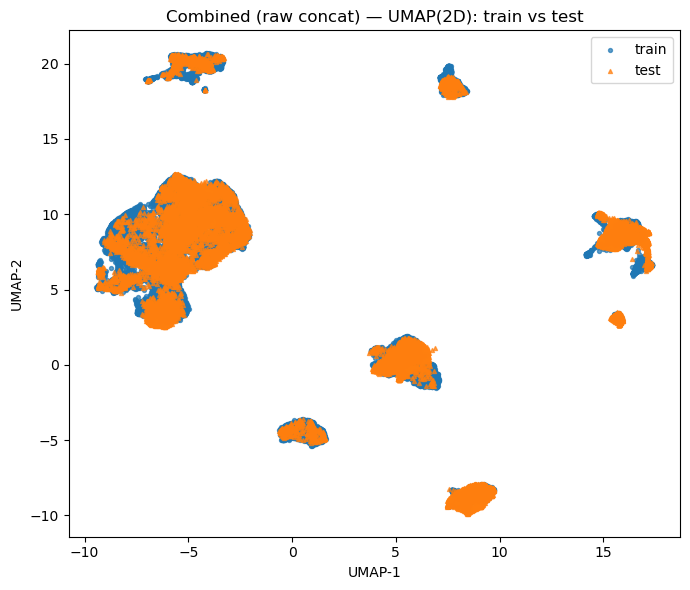

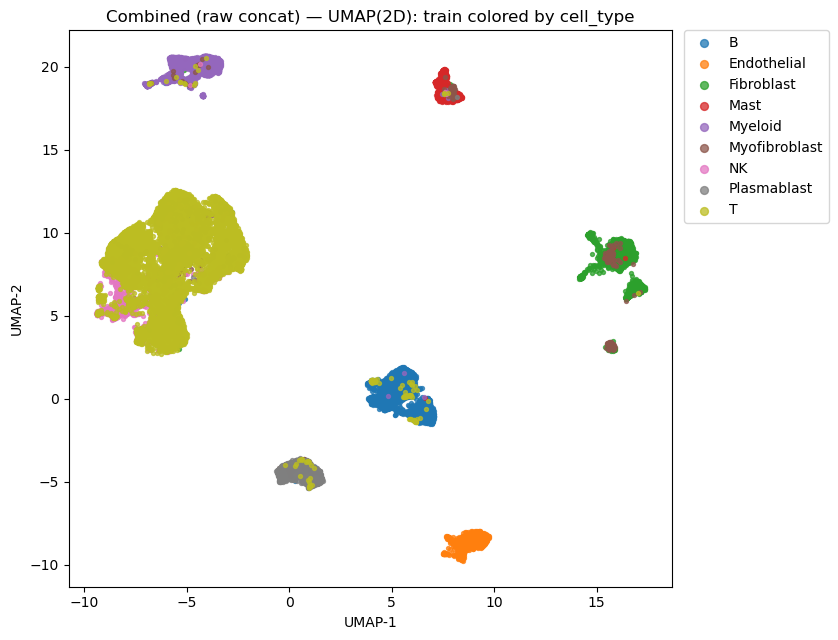

C:\Users\wani\AppData\Local\Temp\ipykernel_14008\1785116702.py:32: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)
c:\Users\wani\AppData\Local\anaconda3\envs\ML4G_project2\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


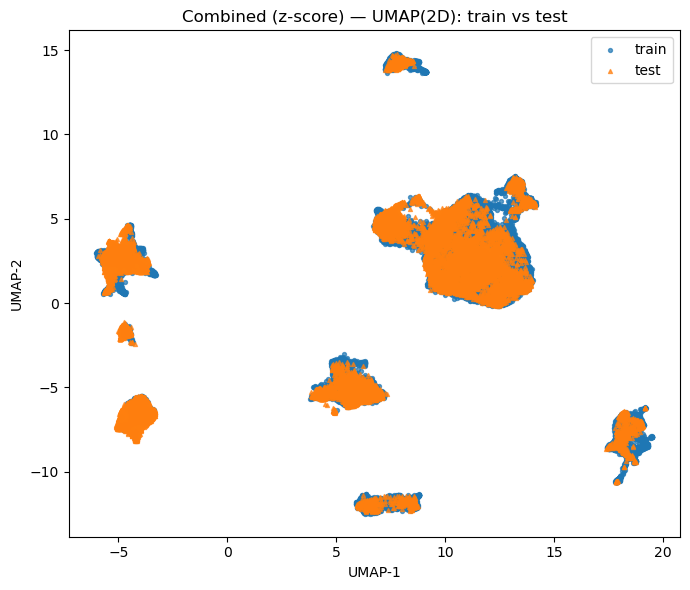

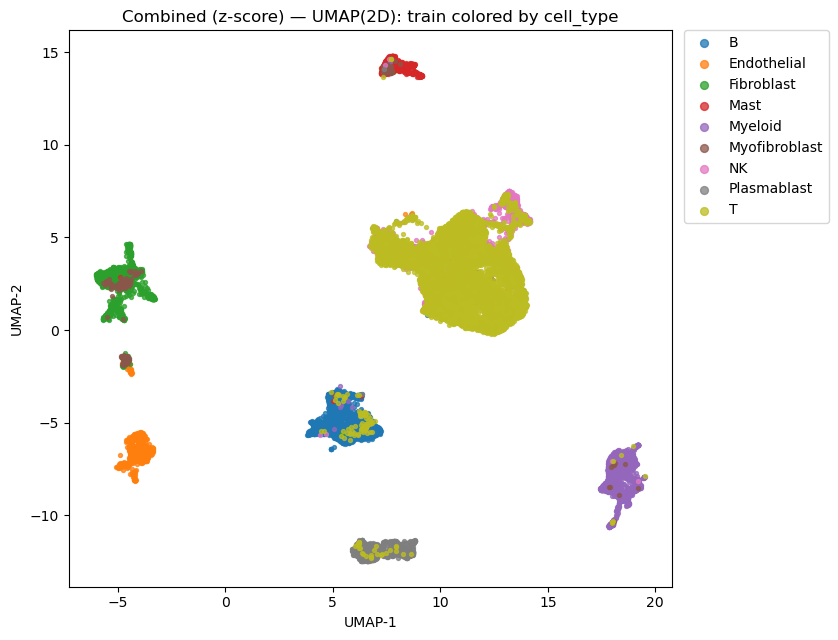

In [13]:
# file: scripts/plot_umap_2d_train_test_and_ct.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# UMAP (pip install umap-learn)
try:
    import umap
except Exception as e:
    raise RuntimeError("需要安裝 umap-learn：pip install umap-learn") from e

IN_DIR = "./outputs_features_csv"
FILES = {
    "Combined (raw concat)": "features_combined.csv",
    "Combined (z-score)":    "features_combined_z-score.csv",
}

LABEL_COL = "cell_type"  # why: 上色/劃分
SET_COL = "set"          # why: train/test 分隔
RANDOM_STATE = 42

# UMAP hyperparams（可依需要調）
N_NEIGHBORS = 15         # why: 小群/局部結構
MIN_DIST    = 0.1
METRIC      = "euclidean"

def load_df(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty dataframe: {path}")
    return df

def get_masks(df: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    """why: 以 set 欄為準；不在就用 cell_type 有無視為 train/test。"""
    if SET_COL in df.columns:
        s = df[SET_COL].astype(str).str.lower()
        is_train = s.eq("train")
        is_test  = s.eq("test")
        if not is_train.any() and LABEL_COL in df.columns:
            is_train = df[LABEL_COL].notna()
            is_test  = ~is_train
    else:
        if LABEL_COL in df.columns:
            is_train = df[LABEL_COL].notna()
            is_test  = ~is_train
        else:
            is_train = pd.Series(True, index=df.index)
            is_test  = ~is_train
    return is_train, is_test

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """why: 僅數值欄；丟全 NaN/常數；不做標準化（需求指定）"""
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features after constant-column filtering.")
    # 填 NaN（UMAP 不能吃 NaN）
    Xdf = Xdf.fillna(Xdf.median(numeric_only=True))
    return Xdf

def run_umap(X: np.ndarray) -> np.ndarray:
    """why: 不標準化；直接以原尺度嵌入"""
    reducer = umap.UMAP(
        n_neighbors=N_NEIGHBORS,
        min_dist=MIN_DIST,
        n_components=2,
        metric=METRIC,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=False,
    )
    return reducer.fit_transform(X)

def scatter_train_vs_test(Z: np.ndarray, is_train: pd.Series, title: str):
    plt.figure(figsize=(7, 6))
    plt.scatter(Z[is_train.values, 0], Z[is_train.values, 1], s=8, alpha=0.7, marker='o', label='train')
    if (~is_train).any():
        plt.scatter(Z[~is_train.values, 0], Z[~is_train.values, 1], s=8, alpha=0.7, marker='^', label='test')
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title(title)
    plt.legend()
    plt.tight_layout(); plt.show()

def scatter_train_by_ct(Z: np.ndarray, df: pd.DataFrame, is_train: pd.Series, title: str):
    if LABEL_COL not in df.columns:
        print("[Info] no 'cell_type' column; skip CT-colored plot.")
        return
    ct = df.loc[is_train, LABEL_COL].astype(str).fillna("NA")
    Zt = Z[is_train.values]
    # 排序：TARGET_ORDER 先，其他字母序
    if 'TARGET_ORDER' in globals() and isinstance(TARGET_ORDER, (list, tuple)):
        known = [c for c in TARGET_ORDER if c in ct.unique()]
        rest = sorted([c for c in ct.unique() if c not in known])
        order = known + rest
    else:
        order = sorted(ct.unique())

    plt.figure(figsize=(8.5, 6.5))
    for k in order:
        m = (ct == k).values
        if not np.any(m): 
            continue
        plt.scatter(Zt[m, 0], Zt[m, 1], s=8, alpha=0.75, label=str(k))
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title(title)
    plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout(); plt.show()

def main():
    for name, fname in FILES.items():
        path = os.path.join(IN_DIR, fname)
        df = load_df(path)
        is_train, is_test = get_masks(df)
        Xdf = numeric_feature_matrix(df)
        Z = run_umap(Xdf.to_numpy())

        # 1) train vs test
        scatter_train_vs_test(
            Z, is_train,
            title=f"{name} — UMAP(2D): train vs test"
        )
        # 2) train colored by cell_type
        scatter_train_by_ct(
            Z, df, is_train,
            title=f"{name} — UMAP(2D): train colored by cell_type"
        )

if __name__ == "__main__":
    main()


# New

In [ ]:
# file: scripts/lgbm_two_stage_kfold_fixedthr_predict_test.py
# -*- coding: utf-8 -*-
"""
Two-pass with shared folds + per-fold ARI/V/Score:
1) Stage-1 Binary KFold -> collect OOF p(T) and test p(T) per fold.
2) Stage-2 non-T Multiclass using same folds; per-fold validation combines binary mask (that fold) + non-T probs -> ARI/V/Score per fold + mean.
Test uses FIXED mask from fold-mean p(T); only ~mask run through non-T multiclass; merge and export.

Why: report fold-wise clustering quality (ARI, V, Score=(ARI+V)/2) while keeping a fixed T mask for test.
"""

import os
from typing import Tuple, Dict, List, Optional, Iterable

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv"
OUT_DIR = "./outputs_features_csv"
FILES = {
    "Combined (z-score)": "features_combined_z-score.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample", "set"]
N_SPLITS = 5
SEED = 42

# Fixed threshold for Stage-1 p(T)
FIXED_THRESHOLD = 0.55

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance via sample weights
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0


# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df


def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab


def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)


def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None


def make_sample_weights(y_like: Iterable,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    ser = pd.Series(list(y_like))
    vc = ser.value_counts()
    K = float(vc.shape[0])
    N = float(len(ser))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = ser.map(w_c).to_numpy(dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w


def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )


def softmax_rows(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    a = np.clip(a, eps, None)
    s = a.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return a / s


def build_shared_folds(X_lab: np.ndarray, y_lab_str: np.ndarray, groups_lab: Optional[np.ndarray]):
    if groups_lab is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        folds = list(splitter.split(X_lab, y_lab_str, groups_lab))
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        folds = list(splitter.split(X_lab, y_lab_str))
    return folds


# ---------------- Stage-1: Binary (shared folds) ----------------
def run_binary_cv_with_folds(
    X_lab: np.ndarray,
    y_lab_str: np.ndarray,
    X_unlab: np.ndarray,
    folds: List[Tuple[np.ndarray, np.ndarray]],
) -> Dict[str, any]:
    yb = (pd.Series(y_lab_str) == POS_LABEL).astype(int).to_numpy()
    yb_lbl = np.where(yb == 1, POS_LABEL, "nonT")
    sw_bin = make_sample_weights(yb_lbl) if USE_SAMPLE_WEIGHTS else np.ones_like(yb, dtype=float)

    oof_pT = np.zeros(X_lab.shape[0], dtype=float)
    test_fold_pT: List[np.ndarray] = []
    rows = []

    for fold_no, (tr_idx, va_idx) in enumerate(folds, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr, y_va = yb[tr_idx], yb[va_idx]

        clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        clf.fit(
            X_tr, y_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, y_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)]
        )
        best_it = clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]

        p_va = clf.predict_proba(X_va, num_iteration=best_it)[:, 1]
        oof_pT[va_idx] = p_va

        # simple binary metrics @ fixed thr (for reference)
        pred_va = (p_va >= FIXED_THRESHOLD).astype(int)
        m = dict(
            ACC=accuracy_score(y_va, pred_va),
            BalACC=balanced_accuracy_score(y_va, pred_va),
            F1=f1_score(y_va, pred_va, average="binary"),
            best_iter=best_it,
        )
        rows.append({"fold": fold_no, **m})

        if X_unlab is not None and X_unlab.shape[0] > 0:
            p_test = clf.predict_proba(X_unlab, num_iteration=best_it)[:, 1]
            test_fold_pT.append(p_test)

    df_cv_bin = pd.DataFrame(rows)
    if not df_cv_bin.empty:
        mean_row = {c: (df_cv_bin[c].mean() if c not in ["fold"] else "mean") for c in df_cv_bin.columns}
        df_cv_bin = pd.concat([df_cv_bin, pd.DataFrame([mean_row])], ignore_index=True)
        print("\n[Stage-1 Binary CV metrics @ fixed thr]")
        print(df_cv_bin.to_string(index=False))

    pT_mean = np.mean(np.vstack(test_fold_pT), axis=0) if test_fold_pT else np.array([])
    return dict(oof_pT=oof_pT, test_fold_pT=test_fold_pT, pT_mean=pT_mean, df_cv_bin=df_cv_bin)


# ---------------- Stage-2: non-T Multiclass (shared folds) ----------------
def run_nonT_multiclass_with_folds(
    X_lab: np.ndarray,
    y_lab_str: np.ndarray,
    X_unlab: np.ndarray,
    folds: List[Tuple[np.ndarray, np.ndarray]],
    nonT_classes: List[str],
    per_fold_p_va_T: List[Tuple[np.ndarray, np.ndarray]],
) -> Dict[str, any]:
    """
    Train non-T multiclass per fold, compute per-fold ARI/V/Score on validation by combining that fold's binary p_va_T + fixed threshold.
    Also collect test non-T probabilities per fold for later averaging.
    """
    nonT_to_idx = {c: i for i, c in enumerate(nonT_classes)}
    K_nonT = len(nonT_classes)

    # For training non-T only
    y_lab_series = pd.Series(y_lab_str)
    lab_nonT_mask_all = (y_lab_series != POS_LABEL).to_numpy()

    # Stable non-T weights over the whole non-T pool
    sw_nonT_all = make_sample_weights(y_lab_series[lab_nonT_mask_all]) if USE_SAMPLE_WEIGHTS else None

    rows = []
    test_fold_nonT: List[np.ndarray] = []

    # For validation metrics: we need predictions over each fold's va set
    y_va_true_all = []
    y_va_pred_all = []  # string labels after merge

    for fold_no, (tr_idx, va_idx) in enumerate(folds, 1):
        # binary val probs for this fold (indices, p_va_T)
        va_idx_b, p_va_T = per_fold_p_va_T[fold_no - 1]
        assert np.array_equal(va_idx_b, va_idx), "Shared folds mismatch between stages."

        # Build non-T training subset inside this fold (use only tr_idx & non-T)
        tr_nonT_mask = lab_nonT_mask_all[tr_idx]
        if not np.any(tr_nonT_mask):
            # Fallback: uniform probs
            proba_va_nonT = np.full((len(va_idx), K_nonT), 1.0 / K_nonT, dtype=float)
            proba_test_nonT = np.full((X_unlab.shape[0], K_nonT), 1.0 / K_nonT, dtype=float)
            best_it = 0
        else:
            X_tr_nonT = X_lab[tr_idx][tr_nonT_mask]
            y_tr_nonT_str = y_lab_series.iloc[tr_idx].to_numpy()[tr_nonT_mask]
            y_tr_nonT = np.array([nonT_to_idx[c] for c in y_tr_nonT_str], dtype=int)

            # Optional eval set: use non-T part of va for early stopping if present
            va_nonT_mask = lab_nonT_mask_all[va_idx]
            eval_set = None
            if np.any(va_nonT_mask):
                X_va_nonT = X_lab[va_idx][va_nonT_mask]
                y_va_nonT_str = y_lab_series.iloc[va_idx].to_numpy()[va_nonT_mask]
                y_va_nonT = np.array([nonT_to_idx[c] for c in y_va_nonT_str], dtype=int)
                eval_set = [(X_va_nonT, y_va_nonT)]

            # Weights mapped from global non-T pool for stability
            sw_tr = None
            if USE_SAMPLE_WEIGHTS and sw_nonT_all is not None:
                sw_map = {cls: w for cls, w in zip(y_lab_series[lab_nonT_mask_all], sw_nonT_all)}
                sw_tr = np.array([sw_map[c] for c in y_tr_nonT_str], dtype=float)

            clf = lgb.LGBMClassifier(num_class=K_nonT, **LGB_PARAMS_MULTI)
            clf.fit(
                X_tr_nonT, y_tr_nonT,
                sample_weight=sw_tr,
                eval_set=eval_set,
                eval_metric="multi_logloss",
                callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)] if eval_set else None,
            )
            best_it = clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]

            # non-T probs for full va and full test (we'll later gate by mask)
            proba_va_nonT = clf.predict_proba(X_lab[va_idx], num_iteration=best_it)
            proba_test_nonT = clf.predict_proba(X_unlab, num_iteration=best_it) if X_unlab.size else np.zeros((0, K_nonT))

        # Merge for validation of this fold
        y_va_true = y_lab_series.iloc[va_idx].to_numpy()
        y_va_pred = np.empty_like(y_va_true, dtype=object)

        bin_T_mask = (p_va_T >= FIXED_THRESHOLD)
        y_va_pred[bin_T_mask] = POS_LABEL
        if K_nonT > 0:
            arg_nonT = np.argmax(proba_va_nonT, axis=1)
            inv_nonT = np.array(nonT_classes, dtype=object)
            y_va_pred[~bin_T_mask] = inv_nonT[arg_nonT[~bin_T_mask]]

        # Compute ARI, V, Score for this fold
        le_metric = LabelEncoder().fit(list(set(y_lab_series)))
        y_true_enc = le_metric.transform(y_va_true)
        y_pred_enc = le_metric.transform(y_va_pred)
        m = dict(
            ARI=adjusted_rand_score(y_true_enc, y_pred_enc),
            V=v_measure_score(y_true_enc, y_pred_enc),
        )
        m["Score"] = 0.5 * (m["ARI"] + m["V"])
        rows.append({"fold": fold_no, "ARI": m["ARI"], "V": m["V"], "Score": m["Score"], "best_iter_nonT": int(best_it)})

        # collect for mean (not strictly needed for ARI/V)
        y_va_true_all.append(y_true_enc)
        y_va_pred_all.append(y_pred_enc)

        # store test non-T probs for later averaging
        if X_unlab.size:
            test_fold_nonT.append(proba_test_nonT)

    df_cv_stage2 = pd.DataFrame(rows)
    if not df_cv_stage2.empty:
        mean_row = {
            "fold": "mean",
            "ARI": df_cv_stage2["ARI"].mean(),
            "V": df_cv_stage2["V"].mean(),
            "Score": df_cv_stage2["Score"].mean(),
            "best_iter_nonT": df_cv_stage2["best_iter_nonT"].mean(),
        }
        df_cv_stage2 = pd.concat([df_cv_stage2, pd.DataFrame([mean_row])], ignore_index=True)
        print("\n[Stage-2 non-T Multiclass + Binary-Mask CV metrics (per fold)]")
        print(df_cv_stage2.to_string(index=False))
        print(f"\n[Final mean Score (ARI+V)/2] = {mean_row['Score']:.6f}")

    return dict(df_cv_stage2=df_cv_stage2, test_fold_nonT=test_fold_nonT)


# ---------------- Orchestration ----------------
def run_two_pass_fixed_mask_with_scores(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows for training.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_str_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    X_lab = X_all[is_lab.values]
    y_lab_str = y_str_all[is_lab.values]
    idx_lab = idx_all[is_lab.values]

    X_unlab = X_all[is_unlab.values]
    idx_unlab = idx_all[is_unlab.values]

    le_all = LabelEncoder().fit(y_lab_str)
    classes_all = le_all.classes_.tolist()
    if POS_LABEL not in classes_all:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not in labels {classes_all}")
    nonT_classes = [c for c in classes_all if c != POS_LABEL]
    if len(nonT_classes) == 0:
        raise ValueError("No non-T classes present in labeled data.")

    groups_lab = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)

    # Shared folds for both stages
    folds = build_shared_folds(X_lab, y_lab_str, groups_lab)

    # ===== Stage-1: Binary (build OOF p_va_T and test fold probs) =====
    print("\n=== Stage-1: Binary (shared folds) ===")
    bin_res = run_binary_cv_with_folds(X_lab, y_lab_str, X_unlab, folds)
    oof_pT = bin_res["oof_pT"]
    test_fold_pT = bin_res["test_fold_pT"]
    pT_mean = bin_res["pT_mean"]

    # keep per-fold (va_idx, p_va_T) for Stage-2 merging
    per_fold_p_va_T = []
    for (tr_idx, va_idx), _ in zip(folds, range(len(folds))):
        per_fold_p_va_T.append((np.array(va_idx), oof_pT[va_idx]))

    # ===== Stage-2: non-T Multiclass (compute per-fold ARI/V/Score) =====
    print("\n=== Stage-2: non-T Multiclass (shared folds, fold-wise ARI/V/Score) ===")
    stage2_res = run_nonT_multiclass_with_folds(
        X_lab, y_lab_str, X_unlab, folds, nonT_classes, per_fold_p_va_T
    )
    test_fold_nonT = stage2_res["test_fold_nonT"]

    # ===== Fixed mask for TEST from Stage-1 pT_mean =====
    if X_unlab.shape[0] > 0 and len(test_fold_pT) > 0:
        mask_fixed = (pT_mean >= FIXED_THRESHOLD)
        print(f"\n[Fixed Mask] test n={len(idx_unlab)} | T={int(mask_fixed.sum())} ({mask_fixed.mean()*100:.2f}%)")
    else:
        mask_fixed = np.array([], dtype=bool)

    # ===== Build final TEST predictions =====
    if X_unlab.shape[0] > 0 and len(test_fold_nonT) > 0:
        proba_nonT_mean = np.mean(np.stack(test_fold_nonT, axis=0), axis=0)  # (n_test, K_nonT)

        pred_final = np.empty(len(idx_unlab), dtype=object)
        pred_final[mask_fixed] = POS_LABEL
        if len(nonT_classes) > 0:
            arg_nonT = np.argmax(proba_nonT_mean, axis=1)
            inv_nonT = np.array(nonT_classes, dtype=object)
            pred_final[~mask_fixed] = inv_nonT[arg_nonT[~mask_fixed]]

        # full prob matrix
        proba_nonT_norm = softmax_rows(
            np.where(proba_nonT_mean.sum(1, keepdims=True) > 0,
                     proba_nonT_mean,
                     np.full_like(proba_nonT_mean, 1.0 / max(1, len(nonT_classes))))
        )
        proba_full = np.zeros((len(idx_unlab), len(classes_all)), dtype=float)
        t_col = classes_all.index(POS_LABEL)
        proba_full[:, t_col] = pT_mean
        for j, cls in enumerate(nonT_classes):
            proba_full[:, classes_all.index(cls)] = (1.0 - pT_mean) * proba_nonT_norm[:, j]

        out = pd.DataFrame({"cell_id": idx_unlab, "pT_mean": pT_mean, "thr_used": FIXED_THRESHOLD})
        out["pred_final"] = pred_final
        for cls in classes_all:
            out[f"proba_{cls}"] = proba_full[:, classes_all.index(cls)]

        print("\n[Test prediction distribution (%)]")
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
        out = pd.DataFrame()

    return out


# ---------------- Main ----------------
if __name__ == "__main__":
    os.makedirs(OUT_DIR, exist_ok=True)
    for name, fname in FILES.items():
        print(f"\n=== Two-PASS (Binary→FixedMask for test; Fold-wise ARI/V for val) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_two_pass_fixed_mask_with_scores(df, fname)
        if not pred.empty:
            out_path = os.path.join(OUT_DIR, f"pred_two_pass_fixedmask_{os.path.splitext(fname)[0]}.csv")
            # pred.to_csv(out_path, index=False)
            print(f"[Saved] {out_path}")



=== Two-PASS (Binary→FixedMask for test; Fold-wise ARI/V for val) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_74648/895716881.py:75: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)



=== Stage-1: Binary (shared folds) ===
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004544 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12558
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:Bo

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 12558, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.079307
[LightGBM] [Info] Start training from score -

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 12559, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.079585
[LightGBM] [Info] Start training from score -

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[Stage-2 non-T Multiclass + Binary-Mask CV metrics (per fold)]
fold      ARI        V    Score  best_iter_nonT
   1 0.880620 0.847051 0.863836            62.0
   2 0.872620 0.843212 0.857916            66.0
   3 0.875657 0.848026 0.861842            72.0
   4 0.880708 0.847442 0.864075            69.0
   5 0.875551 0.851104 0.863328            74.0
mean 0.877031 0.847367 0.862199            68.6

[Final mean Score (ARI+V)/2] = 0.862199

[Fixed Mask] test n=18616 | T=8887 (47.74%)

[Test prediction distribution (%)]
pred_final
B                13.93%
Endothelial      12.34%
Fibroblast       12.13%
Mast              2.26%
Myeloid           2.99%
Myofibroblast     3.62%
NK                3.38%
Plasmablast       1.62%
T                47.74%
Name: p

In [9]:
pred

,cell_id,pT_mean,thr_used,pred_final,proba_B,proba_Endothelial,proba_Fibroblast,proba_Mast,proba_Myeloid,proba_Myofibroblast,proba_NK,proba_Plasmablast,proba_T
0,AAACCCAAGGAGGCAG-1_5-test,0.994992,0.55,T,0.000015,0.000005,0.000007,0.000005,0.000005,0.000006,0.004958,0.000006,0.994992
1,AAACCCAAGTTGCGCC-1_5-test,0.996216,0.55,T,0.003536,0.000028,0.000010,0.000010,0.000009,0.000086,0.000092,0.000013,0.996216
2,AAACCCACACGGATCC-1_5-test,0.972227,0.55,T,0.000149,0.000057,0.000073,0.000049,0.000050,0.000242,0.027079,0.000075,0.972227
3,AAACCCACATCGGAAG-1_5-test,0.985438,0.55,T,0.000716,0.000065,0.000061,0.000130,0.000060,0.013222,0.000225,0.000082,0.985438
4,AAACCCAGTGCGAGTA-1_5-test,0.987704,0.55,T,0.003456,0.003121,0.000071,0.000064,0.000065,0.000165,0.004867,0.000487,0.987704
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18611,TTTGGTTCATTGAAGA-1_10-test,0.972029,0.55,T,0.004346,0.000365,0.000385,0.000361,0.000355,0.002040,0.019726,0.000394,0.972029
18612,TTTGGTTGTTGTCCCT-1_10-test,0.000491,0.55,Fibroblast,0.000540,0.001671,0.994506,0.000540,0.000544,0.000631,0.000539,0.000538,0.000491
18613,TTTGGTTGTTTGACAC-1_10-test,0.012415,0.55,NK,0.000603,0.000599,0.000605,0.000680,0.000664,0.001024,0.982748,0.000662,0.012415
18614,TTTGTTGAGGGTCAAC-1_10-test,0.986916,0.55,T,0.005940,0.000483,0.000545,0.000504,0.000460,0.002827,0.001862,0.000463,0.986916


In [10]:
# Jupyter cell: build cluster_membership.csv from in-memory `pred` only
import os
import re
import pandas as pd
import scanpy as sc

# ---- Settings ----
TEST_AD_PATH     = "../test_data/test_adata.h5ad"
OUT_CLUSTER_CSV  = "../workflow/outputs/cluster_membership_new.csv"
STRIP_TEST_SUFFIX = True  # True: 比對前移除 cell_id 結尾的 "-test"

# ---- Guards ----
if "pred" not in globals() or not isinstance(pred, pd.DataFrame):
    raise RuntimeError("需要記憶體中的 DataFrame `pred`（含 columns: cell_id, pred_final）。")

need_cols = {"cell_id", "pred_final"}
missing = need_cols - set(pred.columns)
if missing:
    raise ValueError(f"`pred` 缺少欄位: {missing}. 需要 {need_cols}")

df_pred = pred[list(need_cols)].copy()

# ---- Normalize cell_id for matching ----
if STRIP_TEST_SUFFIX:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str).str.replace(r"-test$", "", regex=True)
else:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str)

# ---- Load test obs order ----
ad_te = sc.read_h5ad(TEST_AD_PATH)
test_order = pd.Index(ad_te.obs_names.astype(str))

# ---- Align & reorder to test order ----
pred_idx = pd.Index(df_pred["cell_id_std"])
common   = test_order.intersection(pred_idx)
if common.empty:
    raise ValueError("pred 的 cell_id 與 test obs_names 沒有交集（檢查 -test 尾碼或命名）。")

df_pred_idxed = (
    df_pred.set_index("cell_id_std", drop=False)
           .loc[common, ["cell_id", "pred_final"]]
           .rename_axis("cell_id_std")
           .reset_index(drop=True)
)
# 使輸出的 cell_id 與 test 完全一致（不帶 '-test'）
df_pred_idxed["cell_id"] = common.values

if len(common) < len(test_order):
    missing_n = len(test_order) - len(common)
    print(f"[Info] test n={len(test_order)}，pred 可對齊 n={len(common)}；缺少 {missing_n} 列未在 pred 中。")

# ---- Build cluster mapping (1..K) ----
labels = df_pred_idxed["pred_final"].astype(str)
uniq_labels = sorted(labels.unique().tolist())

use_order = None
if "TARGET_ORDER" in globals():
    to_set = set(TARGET_ORDER)
    if set(uniq_labels).issubset(to_set):
        use_order = [ct for ct in TARGET_ORDER if ct in uniq_labels]
if use_order is None:
    use_order = uniq_labels  # 字母序穩定

label_to_cluster = {lab: i+1 for i, lab in enumerate(use_order)}  # 1..K

# ---- Compose and save cluster_membership ----
df_cluster = pd.DataFrame({
    "index": df_pred_idxed["cell_id"].values,                           # 與 test obs_names 完全一致的順序
    "cluster": labels.map(label_to_cluster).astype(int).values
})
if df_cluster["index"].duplicated().any():
    raise ValueError("cluster_membership 中 index 出現重複，請檢查。")
if (df_cluster["cluster"] <= 0).any():
    raise ValueError("cluster 必須為正整數（>=1）。")

df_cluster.to_csv(OUT_CLUSTER_CSV, index=True)  # 依你的示例，保留 pandas 行索引
print(f"[OK] wrote cluster_membership: {OUT_CLUSTER_CSV} | rows={len(df_cluster)}")

print("\n(label -> cluster) mapping:")
print(pd.Series(label_to_cluster).to_string())

print("\n[cluster_membership head]")
print(df_cluster.head(10).to_csv(index=True))


[OK] wrote cluster_membership: ../workflow/outputs/cluster_membership_new.csv | rows=18616

(label -> cluster) mapping:
B                1
Endothelial      2
Fibroblast       3
Mast             4
Myeloid          5
Myofibroblast    6
NK               7
Plasmablast      8
T                9

[cluster_membership head]
,index,cluster
0,AAACCCAAGGAGGCAG-1_5,9
1,AAACCCAAGTTGCGCC-1_5,9
2,AAACCCACACGGATCC-1_5,9
3,AAACCCACATCGGAAG-1_5,9
4,AAACCCAGTGCGAGTA-1_5,9
5,AAACCCATCACGAACT-1_5,9
6,AAACGAAAGTAGAATC-1_5,9
7,AAACGAACAGAGATGC-1_5,9
8,AAACGAATCAAGAATG-1_5,3
9,AAACGAATCCACAAGT-1_5,7



In [33]:
# file: scripts/lgbm_two_stage_kfold_fixedthr_predict_test.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_2"
OUT_DIR = "./outputs_features_csv/new_3"
FILES = {
    "Combined (z-score)":    "features_combined_zscore.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample"]
N_SPLITS  = 5
SEED      = 42

# 固定門檻
FIXED_THRESHOLD = 0.55

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance：樣本權重（不改分布）
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df

def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        # 全部皆視為未標籤
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)

def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None

def make_sample_weights(y_like: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    vc = pd.Series(y_like).value_counts()
    K = float(vc.shape[0]); N = float(len(y_like))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_like], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def ensure_prob_matrix(proba, K: int) -> np.ndarray:
    if isinstance(proba, list):
        proba = np.column_stack(proba)
    proba = np.asarray(proba, dtype=float)
    if proba.ndim == 1:
        proba = proba.reshape(-1, 1)
    if proba.shape[1] != K:
        # 部分 LGB 版本在二元時回傳 (n, ) 為正類；這裡不會用到（多類用 K）
        pass
    return proba

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

# ---------------- Per-file run ----------------
def run_kfold_and_predict(df: pd.DataFrame, fname: str) -> None:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows for training.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_str_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    # labeled / unlabeled split for training & predicting
    X_lab = X_all[is_lab.values]
    y_str = y_str_all[is_lab.values]
    idx_lab = idx_all[is_lab.values]

    X_unlab = X_all[is_unlab.values]
    idx_unlab = idx_all[is_unlab.values]

    # encoders & constants
    le = LabelEncoder().fit(y_str)
    classes = le.classes_
    if POS_LABEL not in classes:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not in labels {classes.tolist()}")
    idx_T = int(np.where(classes == POS_LABEL)[0][0])
    y = le.transform(y_str)
    y_bin = (y_str == POS_LABEL).astype(int)
    K = len(classes)

    # groups (only for labeled)
    groups = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)

    # split
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X_lab, y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(X_lab, y)

    # weights
    sw_multi = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y, dtype=float)
    yb_lbl = np.where(y_bin==1, POS_LABEL, "nonT")
    sw_bin  = make_sample_weights(yb_lbl) if USE_SAMPLE_WEIGHTS else np.ones_like(y_bin, dtype=float)

    # storage for fold-wise test predictions
    test_bin_probs: List[np.ndarray] = []   # each (n_test,)
    test_multi_probs: List[np.ndarray] = [] # each (n_test, K)

    # report rows
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        yb_tr, yb_va = y_bin[tr_idx], y_bin[va_idx]

        # ===== Binary =====
        bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        bin_clf.fit(
            X_tr, yb_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, yb_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
        p_va = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
        mask_va = (p_va >= FIXED_THRESHOLD)
        # Multiclass for validation metrics (unmask/mask)
        multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        multi_clf.fit(
            X_tr, y_tr,
            sample_weight=sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
        proba_va = ensure_prob_matrix(multi_clf.predict_proba(X_va, num_iteration=best_it_multi), K)
        yhat_unmask = np.argmax(proba_va, axis=1)
        yhat_mask = yhat_unmask.copy()
        yhat_mask[mask_va] = idx_T

        def pack(y_true, y_pred):
            m = metrics_all(y_true, y_pred); m["Score"] = 0.5*(m["ARI"]+m["V"]); return m
        m_base = pack(y_va, yhat_unmask)
        m_mask = pack(y_va, yhat_mask)

        rows.append({
            "fold": fold,
            "val_n": int(len(va_idx)),
            "thr_fixed": FIXED_THRESHOLD,
            "UNMASK_ACC": m_base["ACC"],
            "UNMASK_BalACC": m_base["Balanced_ACC"],
            "UNMASK_F1m": m_base["F1_macro"],
            "UNMASK_ARI": m_base["ARI"],
            "UNMASK_V":   m_base["V"],
            "UNMASK_Score": m_base["Score"],
            "MASK_ACC": m_mask["ACC"],
            "MASK_BalACC": m_mask["Balanced_ACC"],
            "MASK_F1m": m_mask["F1_macro"],
            "MASK_ARI": m_mask["ARI"],
            "MASK_V":   m_mask["V"],
            "MASK_Score": m_mask["Score"],
            "ΔScore": m_mask["Score"] - m_base["Score"],
            "best_iter_bin": int(best_it_bin),
            "best_iter_multi": int(best_it_multi),
        })

        # ===== Predict ALL test rows in this fold =====
        if len(idx_unlab) > 0:
            p_test = bin_clf.predict_proba(X_unlab, num_iteration=best_it_bin)[:, 1]
            test_bin_probs.append(p_test)

            proba_test = ensure_prob_matrix(multi_clf.predict_proba(X_unlab, num_iteration=best_it_multi), K)
            test_multi_probs.append(proba_test)

    # ---- CV summary ----
    df_cv = pd.DataFrame(rows)
    mean_row = {c:(df_cv[c].mean() if c not in ["fold"] else "mean") for c in df_cv.columns}
    df_cv = pd.concat([df_cv, pd.DataFrame([mean_row])], ignore_index=True)
    print("\n[CV metrics]")
    print(df_cv.to_string(index=False))

    # ---- Fold-mean predictions for TEST ----
    if len(idx_unlab) > 0 and len(test_bin_probs) > 0 and len(test_multi_probs) > 0:
        pT_mean = np.mean(np.vstack(test_bin_probs), axis=0)                 # (n_test,)
        proba_mean = np.mean(np.stack(test_multi_probs, axis=0), axis=0)     # (n_test, K)

        # 最終分類
        yhat_unmask = np.argmax(proba_mean, axis=1)
        yhat_mask = yhat_unmask.copy()
        yhat_mask[pT_mean >= FIXED_THRESHOLD] = idx_T

        # 輸出
        out = pd.DataFrame({"cell_id": idx_unlab, "pT_mean": pT_mean, "thr_used": FIXED_THRESHOLD})
        out["pred_unmask"] = le.inverse_transform(yhat_unmask)
        out["pred_final"]  = le.inverse_transform(yhat_mask)
        for i, cls in enumerate(classes):
            out[f"proba_{cls}"] = proba_mean[:, i]
  
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
    return out

# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Two-Stage KFold w/ fixed threshold (0.55) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_kfold_and_predict(df, fname)



=== Two-Stage KFold w/ fixed threshold (0.55) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_74648/2343357581.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005473 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004572 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -2.362116
[LightGBM] [Info] Start training from score -2.178800
[LightGBM] [Info] Start training from score -2.178062
[Ligh

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004902 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[CV metrics]
fold  val_n  thr_fixed  UNMASK_ACC  UNMASK_BalACC  UNMASK_F1m  UNMASK_ARI  UNMASK_V  UNMASK_Score  MASK_ACC  MASK_BalACC  MASK_F1m  MASK_ARI   MASK_V  MASK_Score   ΔScore  best_iter_bin  best_iter_multi
   1 6475.0       0.55    0.940849       0.897889    0.894361    0.878193  0.848213      0.863203  0.944402     0.880302  0.893646  0.887072 0.853966    0.870519 0.007316          153.0             81.0
   2 6475.0       0.55    0.938224       0.898596    0.891055    0.870398  0.842172      0.856285  0.942239     0.879612  0.889157  0.880281 0.847017    0.863649 0.007364          151.0             84.0
   3 6475.0       0.55    0.943784       0.908422    0.905153    0.877940  0.849278      0.863609  0.945637     0.878521  0.893744  0.882622 0.852850    0.867736 0.004127          161.0             89.0
   4 6475.0       0.55    0.945328       0.901991   

In [31]:
# Jupyter cell: build cluster_membership.csv from in-memory `pred` only
import os
import re
import pandas as pd
import scanpy as sc

# ---- Settings ----
TEST_AD_PATH     = "../test_data/test_adata.h5ad"
OUT_CLUSTER_CSV  = "../workflow/outputs/result_2/cluster_membership.csv"
STRIP_TEST_SUFFIX = True  # True: 比對前移除 cell_id 結尾的 "-test"

# ---- Guards ----
if "pred" not in globals() or not isinstance(pred, pd.DataFrame):
    raise RuntimeError("需要記憶體中的 DataFrame `pred`（含 columns: cell_id, pred_final）。")

need_cols = {"cell_id", "pred_final"}
missing = need_cols - set(pred.columns)
if missing:
    raise ValueError(f"`pred` 缺少欄位: {missing}. 需要 {need_cols}")

df_pred = pred[list(need_cols)].copy()

# ---- Normalize cell_id for matching ----
if STRIP_TEST_SUFFIX:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str).str.replace(r"-test$", "", regex=True)
else:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str)

# ---- Load test obs order ----
ad_te = sc.read_h5ad(TEST_AD_PATH)
test_order = pd.Index(ad_te.obs_names.astype(str))

# ---- Align & reorder to test order ----
pred_idx = pd.Index(df_pred["cell_id_std"])
common   = test_order.intersection(pred_idx)
if common.empty:
    raise ValueError("pred 的 cell_id 與 test obs_names 沒有交集（檢查 -test 尾碼或命名）。")

df_pred_idxed = (
    df_pred.set_index("cell_id_std", drop=False)
           .loc[common, ["cell_id", "pred_final"]]
           .rename_axis("cell_id_std")
           .reset_index(drop=True)
)
# 使輸出的 cell_id 與 test 完全一致（不帶 '-test'）
df_pred_idxed["cell_id"] = common.values

if len(common) < len(test_order):
    missing_n = len(test_order) - len(common)
    print(f"[Info] test n={len(test_order)}，pred 可對齊 n={len(common)}；缺少 {missing_n} 列未在 pred 中。")

# ---- Build cluster mapping (1..K) ----
labels = df_pred_idxed["pred_final"].astype(str)
uniq_labels = sorted(labels.unique().tolist())

use_order = None
if "TARGET_ORDER" in globals():
    to_set = set(TARGET_ORDER)
    if set(uniq_labels).issubset(to_set):
        use_order = [ct for ct in TARGET_ORDER if ct in uniq_labels]
if use_order is None:
    use_order = uniq_labels  # 字母序穩定

label_to_cluster = {lab: i+1 for i, lab in enumerate(use_order)}  # 1..K

# ---- Compose and save cluster_membership ----
df_cluster = pd.DataFrame({
    "index": df_pred_idxed["cell_id"].values,                           # 與 test obs_names 完全一致的順序
    "cluster": labels.map(label_to_cluster).astype(int).values
})
if df_cluster["index"].duplicated().any():
    raise ValueError("cluster_membership 中 index 出現重複，請檢查。")
if (df_cluster["cluster"] <= 0).any():
    raise ValueError("cluster 必須為正整數（>=1）。")

df_cluster.to_csv(OUT_CLUSTER_CSV, index=True)  # 依你的示例，保留 pandas 行索引
print(f"[OK] wrote cluster_membership: {OUT_CLUSTER_CSV} | rows={len(df_cluster)}")

print("\n(label -> cluster) mapping:")
print(pd.Series(label_to_cluster).to_string())

print("\n[cluster_membership head]")
print(df_cluster.head(10).to_csv(index=True))


[OK] wrote cluster_membership: ../workflow/outputs/result_2/cluster_membership.csv | rows=18616

(label -> cluster) mapping:
T    1

[cluster_membership head]
,index,cluster
0,AAACCCAAGGAGGCAG-1_5,1
1,AAACCCAAGTTGCGCC-1_5,1
2,AAACCCACACGGATCC-1_5,1
3,AAACCCACATCGGAAG-1_5,1
4,AAACCCAGTGCGAGTA-1_5,1
5,AAACCCATCACGAACT-1_5,1
6,AAACGAAAGTAGAATC-1_5,1
7,AAACGAACAGAGATGC-1_5,1
8,AAACGAATCAAGAATG-1_5,1
9,AAACGAATCCACAAGT-1_5,1



/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_74648/17783960.py:27: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


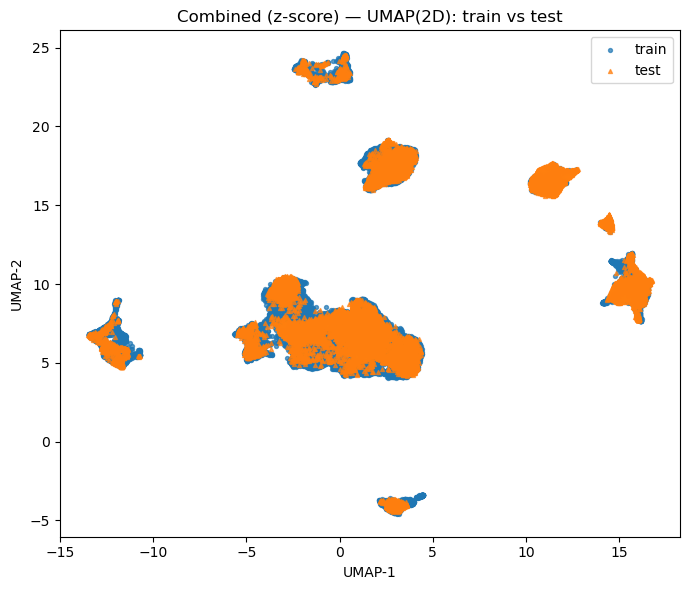

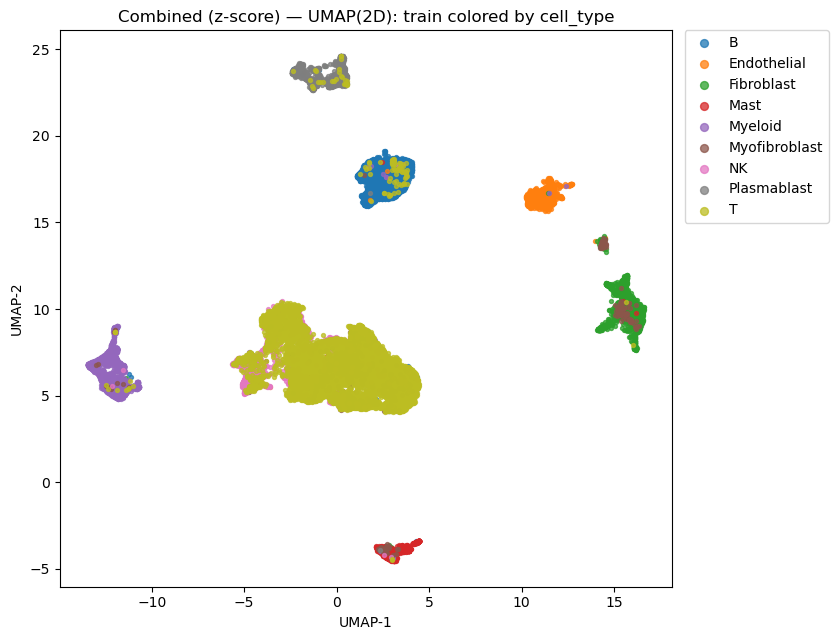

In [34]:
# file: scripts/plot_umap_2d_train_test_and_ct.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# UMAP (pip install umap-learn)
try:
    import umap
except Exception as e:
    raise RuntimeError("需要安裝 umap-learn：pip install umap-learn") from e


LABEL_COL = "cell_type"  # why: 上色/劃分
SET_COL = "set"          # why: train/test 分隔
RANDOM_STATE = 42

# UMAP hyperparams（可依需要調）
N_NEIGHBORS = 15         # why: 小群/局部結構
MIN_DIST    = 0.1
METRIC      = "euclidean"

def load_df(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Not found: {path}")
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty dataframe: {path}")
    return df

def get_masks(df: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    """why: 以 set 欄為準；不在就用 cell_type 有無視為 train/test。"""
    if SET_COL in df.columns:
        s = df[SET_COL].astype(str).str.lower()
        is_train = s.eq("train")
        is_test  = s.eq("test")
        if not is_train.any() and LABEL_COL in df.columns:
            is_train = df[LABEL_COL].notna()
            is_test  = ~is_train
    else:
        if LABEL_COL in df.columns:
            is_train = df[LABEL_COL].notna()
            is_test  = ~is_train
        else:
            is_train = pd.Series(True, index=df.index)
            is_test  = ~is_train
    return is_train, is_test

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    """why: 僅數值欄；丟全 NaN/常數；不做標準化（需求指定）"""
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features after constant-column filtering.")
    # 填 NaN（UMAP 不能吃 NaN）
    Xdf = Xdf.fillna(Xdf.median(numeric_only=True))
    return Xdf

def run_umap(X: np.ndarray) -> np.ndarray:
    """why: 不標準化；直接以原尺度嵌入"""
    reducer = umap.UMAP(
        n_neighbors=N_NEIGHBORS,
        min_dist=MIN_DIST,
        n_components=2,
        metric=METRIC,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=False,
    )
    return reducer.fit_transform(X)

def scatter_train_vs_test(Z: np.ndarray, is_train: pd.Series, title: str):
    plt.figure(figsize=(7, 6))
    plt.scatter(Z[is_train.values, 0], Z[is_train.values, 1], s=8, alpha=0.7, marker='o', label='train')
    if (~is_train).any():
        plt.scatter(Z[~is_train.values, 0], Z[~is_train.values, 1], s=8, alpha=0.7, marker='^', label='test')
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title(title)
    plt.legend()
    plt.tight_layout(); plt.show()

def scatter_train_by_ct(Z: np.ndarray, df: pd.DataFrame, is_train: pd.Series, title: str):
    if LABEL_COL not in df.columns:
        print("[Info] no 'cell_type' column; skip CT-colored plot.")
        return
    ct = df.loc[is_train, LABEL_COL].astype(str).fillna("NA")
    Zt = Z[is_train.values]
    # 排序：TARGET_ORDER 先，其他字母序
    if 'TARGET_ORDER' in globals() and isinstance(TARGET_ORDER, (list, tuple)):
        known = [c for c in TARGET_ORDER if c in ct.unique()]
        rest = sorted([c for c in ct.unique() if c not in known])
        order = known + rest
    else:
        order = sorted(ct.unique())

    plt.figure(figsize=(8.5, 6.5))
    for k in order:
        m = (ct == k).values
        if not np.any(m): 
            continue
        plt.scatter(Zt[m, 0], Zt[m, 1], s=8, alpha=0.75, label=str(k))
    plt.xlabel("UMAP-1"); plt.ylabel("UMAP-2"); plt.title(title)
    plt.legend(markerscale=2, bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
    plt.tight_layout(); plt.show()

def main():
    for name, fname in FILES.items():
        path = os.path.join(IN_DIR, fname)
        df = load_df(path)
        is_train, is_test = get_masks(df)
        Xdf = numeric_feature_matrix(df)
        Z = run_umap(Xdf.to_numpy())

        # 1) train vs test
        scatter_train_vs_test(
            Z, is_train,
            title=f"{name} — UMAP(2D): train vs test"
        )
        # 2) train colored by cell_type
        scatter_train_by_ct(
            Z, df, is_train,
            title=f"{name} — UMAP(2D): train colored by cell_type"
        )

if __name__ == "__main__":
    main()


In [44]:
# file: scripts/lgbm_two_stage_kfold_fixedthr_predict_test.py
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from typing import Tuple, Dict, List, Optional
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_2"
OUT_DIR = "./outputs_features_csv/new_2"
FILES = {
    "Combined (z-score)":    "features_combined_zscore.csv",
}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample"]
N_SPLITS  = 5
SEED      = 42

# 固定門檻
FIXED_THRESHOLD = 0.55

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Imbalance：樣本權重（不改分布）
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0

# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df

def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        # 全部皆視為未標籤
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)

def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None

def make_sample_weights(y_like: np.ndarray,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    vc = pd.Series(y_like).value_counts()
    K = float(vc.shape[0]); N = float(len(y_like))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = np.array([w_c[y] for y in y_like], dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def ensure_prob_matrix(proba, K: int) -> np.ndarray:
    if isinstance(proba, list):
        proba = np.column_stack(proba)
    proba = np.asarray(proba, dtype=float)
    if proba.ndim == 1:
        proba = proba.reshape(-1, 1)
    if proba.shape[1] != K:
        # 部分 LGB 版本在二元時回傳 (n, ) 為正類；這裡不會用到（多類用 K）
        pass
    return proba

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

# ---------------- Per-file run ----------------
def run_kfold_and_predict(df: pd.DataFrame, fname: str) -> None:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows for training.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_str_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    # labeled / unlabeled split for training & predicting
    X_lab = X_all[is_lab.values]
    y_str = y_str_all[is_lab.values]
    idx_lab = idx_all[is_lab.values]

    X_unlab = X_all[is_unlab.values]
    idx_unlab = idx_all[is_unlab.values]

    # encoders & constants
    le = LabelEncoder().fit(y_str)
    classes = le.classes_
    if POS_LABEL not in classes:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not in labels {classes.tolist()}")
    idx_T = int(np.where(classes == POS_LABEL)[0][0])
    y = le.transform(y_str)
    y_bin = (y_str == POS_LABEL).astype(int)
    K = len(classes)

    # groups (only for labeled)
    groups = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)

    # split
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        split_iter = splitter.split(X_lab, y, groups)
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = splitter.split(X_lab, y)

    # weights
    sw_multi = make_sample_weights(y_str) if USE_SAMPLE_WEIGHTS else np.ones_like(y, dtype=float)
    yb_lbl = np.where(y_bin==1, POS_LABEL, "nonT")
    sw_bin  = make_sample_weights(yb_lbl) if USE_SAMPLE_WEIGHTS else np.ones_like(y_bin, dtype=float)

    # storage for fold-wise test predictions
    test_bin_probs: List[np.ndarray] = []   # each (n_test,)
    test_multi_probs: List[np.ndarray] = [] # each (n_test, K)

    # report rows
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(split_iter, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]
        yb_tr, yb_va = y_bin[tr_idx], y_bin[va_idx]

        # ===== Binary =====
        bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
        bin_clf.fit(
            X_tr, yb_tr,
            sample_weight=sw_bin[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, yb_va)],
            eval_metric="logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
        p_va = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
        mask_va = (p_va >= FIXED_THRESHOLD)
        # Multiclass for validation metrics (unmask/mask)
        multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
        multi_clf.fit(
            X_tr, y_tr,
            sample_weight=sw_multi[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
        )
        best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
        proba_va = ensure_prob_matrix(multi_clf.predict_proba(X_va, num_iteration=best_it_multi), K)
        yhat_unmask = np.argmax(proba_va, axis=1)
        yhat_mask = yhat_unmask.copy()
        yhat_mask[mask_va] = idx_T

        def pack(y_true, y_pred):
            m = metrics_all(y_true, y_pred); m["Score"] = 0.5*(m["ARI"]+m["V"]); return m
        m_base = pack(y_va, yhat_unmask)
        m_mask = pack(y_va, yhat_mask)

        rows.append({
            "fold": fold,
            "val_n": int(len(va_idx)),
            "thr_fixed": FIXED_THRESHOLD,
            "UNMASK_ACC": m_base["ACC"],
            "UNMASK_BalACC": m_base["Balanced_ACC"],
            "UNMASK_F1m": m_base["F1_macro"],
            "UNMASK_ARI": m_base["ARI"],
            "UNMASK_V":   m_base["V"],
            "UNMASK_Score": m_base["Score"],
            "MASK_ACC": m_mask["ACC"],
            "MASK_BalACC": m_mask["Balanced_ACC"],
            "MASK_F1m": m_mask["F1_macro"],
            "MASK_ARI": m_mask["ARI"],
            "MASK_V":   m_mask["V"],
            "MASK_Score": m_mask["Score"],
            "ΔScore": m_mask["Score"] - m_base["Score"],
            "best_iter_bin": int(best_it_bin),
            "best_iter_multi": int(best_it_multi),
        })

        # ===== Predict ALL test rows in this fold =====
        if len(idx_unlab) > 0:
            p_test = bin_clf.predict_proba(X_unlab, num_iteration=best_it_bin)[:, 1]
            test_bin_probs.append(p_test)

            proba_test = ensure_prob_matrix(multi_clf.predict_proba(X_unlab, num_iteration=best_it_multi), K)
            test_multi_probs.append(proba_test)

    # ---- CV summary ----
    df_cv = pd.DataFrame(rows)
    mean_row = {c:(df_cv[c].mean() if c not in ["fold"] else "mean") for c in df_cv.columns}
    df_cv = pd.concat([df_cv, pd.DataFrame([mean_row])], ignore_index=True)
    print("\n[CV metrics]")
    print(df_cv.to_string(index=False))

    # ---- Fold-mean predictions for TEST ----
    if len(idx_unlab) > 0 and len(test_bin_probs) > 0 and len(test_multi_probs) > 0:
        pT_mean = np.mean(np.vstack(test_bin_probs), axis=0)                 # (n_test,)
        proba_mean = np.mean(np.stack(test_multi_probs, axis=0), axis=0)     # (n_test, K)

        # 最終分類
        yhat_unmask = np.argmax(proba_mean, axis=1)
        yhat_mask = yhat_unmask.copy()
        yhat_mask[pT_mean >= FIXED_THRESHOLD] = idx_T

        # 輸出
        out = pd.DataFrame({"cell_id": idx_unlab, "pT_mean": pT_mean, "thr_used": FIXED_THRESHOLD})
        out["pred_unmask"] = le.inverse_transform(yhat_unmask)
        out["pred_final"]  = le.inverse_transform(yhat_mask)
        for i, cls in enumerate(classes):
            out[f"proba_{cls}"] = proba_mean[:, i]
  
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
    return out

# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Two-Stage KFold w/ fixed threshold (0.55) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_kfold_and_predict(df, fname)



=== Two-Stage KFold w/ fixed threshold (0.55) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_74648/1474008527.py:64: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004838 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005523 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -2.362116
[LightGBM] [Info] Start training from score -2.178800
[LightGBM] [Info] Start training from score -2.178062
[Ligh

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004420 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -2.360056
[LightGBM] [Info] Start training from score -2.178826
[LightGBM] [Info] Start training from score -2.178088
[Ligh

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[CV metrics]
fold  val_n  thr_fixed  UNMASK_ACC  UNMASK_BalACC  UNMASK_F1m  UNMASK_ARI  UNMASK_V  UNMASK_Score  MASK_ACC  MASK_BalACC  MASK_F1m  MASK_ARI   MASK_V  MASK_Score   ΔScore  best_iter_bin  best_iter_multi
   1 6475.0       0.55    0.940695       0.899255    0.894688    0.878022  0.846707      0.862365  0.944247     0.876318  0.889692  0.887141 0.853231    0.870186 0.007822          166.0             79.0
   2 6475.0       0.55    0.937761       0.899025    0.893462    0.866445  0.841809      0.854127  0.944556     0.883229  0.896086  0.882644 0.852281    0.867462 0.013336          163.0             87.0
   3 6475.0       0.55    0.942239       0.900194    0.900597    0.874602  0.846476      0.860539  0.945174     0.877836  0.894239  0.881583 0.852206    0.866895 0.006356          186.0             93.0
   4 6475.0       0.55    0.945792       0.897330   

In [66]:
# file: scripts/ensemble_arbiter_lgbm_knn.py
# -*- coding: utf-8 -*-
"""
Ensemble with an Inner-Fold Arbiter (no outer-val leakage):
- LGBM: two-stage (binary T mask + multiclass).
- KNN: multiclass on ALL classes; hard decision still masked by binary p(T)>=thr.
- Outer CV:
    * Build inner K-fold ONLY on outer-train to create inner-OOF for arbiter training.
    * Train arbiter_inner on inner-OOF features/targets (no outer-val leakage).
    * Train outer LGBM/KNN on full outer-train, get probs on outer-val & test.
    * Arbiter_inner selects model per sample (outer-val & test).
- Report per-fold metrics; test uses fold-wise chosen probs averaged across folds.
"""

import os
from typing import Tuple, Dict, List, Optional, Iterable

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_5"
OUT_DIR = "./outputs_features_csv/new_5"
FILES = {"Combined (z-score)": "features_combined_zscore.csv"}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample"]

# Outer folds for base models
N_SPLITS = 5
# Inner folds to train the arbiter on outer-train only
N_SPLITS_ARBITER = 5

SEED = 42

# Threshold
FIXED_THRESHOLD = 0.55
FORCE_T_BY_BINARY = True  # if pT_mean >= thr (from LGBM binary), force T

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# KNN
K_NEIGHBORS = 10
KNN_METRIC = "cosine"      # "euclidean" / "cosine"
KNN_WEIGHTED_VOTE = False  # distance weighting

# Imbalance → sample weights
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0


# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df


def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab


def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)


def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None


def make_sample_weights(y_like: Iterable,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    ser = pd.Series(list(y_like))
    vc = ser.value_counts()
    K = float(vc.shape[0]); N = float(len(ser))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = ser.map(w_c).to_numpy(dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w


def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )


def entropy_row(p: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    return float(-(p * np.log(p)).sum())


def top1_top2_margin(p: np.ndarray) -> Tuple[float, float, float]:
    idx = np.argsort(-p)
    top1 = p[idx[0]] if len(idx) > 0 else 0.0
    top2 = p[idx[1]] if len(idx) > 1 else 0.0
    return float(top1), float(top2), float(top1 - top2)


def softmax_rows(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    s = a.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return a / s


def features_from_prob(proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return arrays: top1, top2, margin, entropy."""
    t1, t2, mg = [], [], []
    for row in proba:
        a, b, c = top1_top2_margin(row)
        t1.append(a); t2.append(b); mg.append(c)
    ent = np.array([entropy_row(p) for p in proba])
    return np.array(t1), np.array(t2), np.array(mg), ent


# ---------------- KNN helpers ----------------
def knn_predict_proba(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    n_classes: int,
    k: int,
    metric: str = "euclidean",
    weighted: bool = True,
) -> np.ndarray:
    """Return (n_query, n_classes) vote distribution. weighted uses 1/(d+eps)."""
    if X_query.size == 0:
        return np.zeros((0, n_classes), dtype=float)
    k = max(1, min(k, len(X_train)))
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    nbrs.fit(X_train)
    dists, idxs = nbrs.kneighbors(X_query, return_distance=True)

    eps = 1e-12
    proba = np.zeros((X_query.shape[0], n_classes), dtype=float)

    if weighted:
        weights = 1.0 / (dists + eps)
        for i in range(X_query.shape[0]):
            cls = y_train[idxs[i]]
            w = weights[i]
            for c, wj in zip(cls, w):
                proba[i, c] += float(wj)
    else:
        for i in range(X_query.shape[0]):
            cnt = Counter(y_train[idxs[i]])
            for c, v in cnt.items():
                proba[i, c] += float(v)

    return softmax_rows(proba)


# ---------------- LGBM two-stage (per fold) ----------------
def train_predict_lgb_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """Binary T vs non-T → p(T); multiclass (K) → proba; mask T on val; return val/test."""
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str); y_va = le.transform(y_va_str)
    K = len(classes_all)
    idx_T = int(classes_all.index(POS_LABEL))

    # Binary
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass (K)
    multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
    multi_clf.fit(
        X_tr, y_tr,
        sample_weight=sw_multi_tr,
        eval_set=[(X_va, y_va)], eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
    proba_va_k = multi_clf.predict_proba(X_va, num_iteration=best_it_multi)
    proba_test_k = multi_clf.predict_proba(X_test, num_iteration=best_it_multi) if X_test.size else np.zeros((0, K))

    # Mask on validation
    yhat_va = np.argmax(proba_va_k, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T=p_va_T, p_test_T=p_test_T,
        proba_va_k=proba_va_k, proba_test_k=proba_test_k,
        yhat_va=yhat_va, best_it_bin=best_it_bin, best_it_multi=best_it_multi
    )


# ---------------- KNN two-stage (UPDATED: KNN on ALL classes) ----------------
def train_predict_knn_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """
    Binary (LGBM) to get p(T) for mask; KNN multiclass on ALL classes for probs.
    Returns:
      - p_va_T_knn, p_test_T_knn
      - proba_va_full_knn, proba_test_full_knn : (n, K) = raw KNN multiclass probs (no (1-pT) scaling)
      - yhat_va_knn after applying T-mask (p(T)>=thr -> T)
    """
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    # ---- Binary for mask
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # ---- KNN multiclass on ALL classes
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)  # 0..K-1
    proba_va_knn = knn_predict_proba(
        X_tr, y_tr, X_va, n_classes=K,
        k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    )
    proba_test_knn = knn_predict_proba(
        X_tr, y_tr, X_test, n_classes=K,
        k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    ) if X_test.size else np.zeros((0, K))

    # ---- Validation hard decision with mask
    yhat_va = np.argmax(proba_va_knn, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_knn=p_va_T, p_test_T_knn=p_test_T,
        proba_va_full_knn=proba_va_knn, proba_test_full_knn=proba_test_knn,
        yhat_va_knn=yhat_va
    )


# ---------------- Main orchestration (with inner-fold arbiter) ----------------
def run_ensemble_arbiter(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    X_lab, y_lab_str, idx_lab = X_all[is_lab.values], y_all[is_lab.values], idx_all[is_lab.values]
    X_test, idx_test = X_all[is_unlab.values], idx_all[is_unlab.values]

    le_all = LabelEncoder().fit(y_lab_str)
    classes_all = le_all.classes_.tolist()
    if POS_LABEL not in classes_all:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not found in labels {classes_all}")
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    groups = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        folds = list(splitter.split(X_lab, y_lab_str, groups))
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        folds = list(splitter.split(X_lab, y_lab_str))

    # weights
    y_bin_lbl = np.where(pd.Series(y_lab_str) == POS_LABEL, POS_LABEL, "nonT")
    sw_bin_all = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)
    sw_multi_all = make_sample_weights(y_lab_str) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)

    # OOF storages (for single models; ensemble OOF以rows_ens報)
    oof_lgb = np.full(len(y_lab_str), -1, dtype=int)
    oof_knn = np.full(len(y_lab_str), -1, dtype=int)
    oof_lgb_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_knn_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_pT = np.zeros(len(y_lab_str), dtype=float)  # LGBM binary p(T)

    # For test (per outer fold)
    arbiter_per_fold: List[LogisticRegression] = []
    test_fold_meta_inputs: List[Tuple[np.ndarray, np.ndarray, np.ndarray]] = []

    rows = []
    rows_ens = []

    # ---- Outer folds
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr_str, y_va_str = y_lab_str[tr_idx], y_lab_str[va_idx]

        # ===== INNER K for ARBITER (on outer-train only) =====
        inner_splitter = StratifiedKFold(n_splits=min(N_SPLITS_ARBITER, max(2, np.unique(y_tr_str).shape[0])), 
                                         shuffle=True, random_state=SEED+fold)

        tr_len = len(tr_idx)
        oof_lgb_inner = np.full(tr_len, -1, dtype=int)
        oof_knn_inner = np.full(tr_len, -1, dtype=int)
        oof_lgb_proba_inner = np.zeros((tr_len, K), dtype=float)
        oof_knn_proba_inner = np.zeros((tr_len, K), dtype=float)
        oof_pT_inner = np.zeros(tr_len, dtype=float)

        sw_bin_tr_all = sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None
        sw_multi_tr_all = sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None

        for in_fold, (in_tr, in_va) in enumerate(inner_splitter.split(X_tr, y_tr_str), 1):
            X_in_tr, X_in_va = X_tr[in_tr], X_tr[in_va]
            y_in_tr_str, y_in_va_str = y_tr_str[in_tr], y_tr_str[in_va]

            # LGBM two-stage (inner)
            lgb_res_in = train_predict_lgb_two_stage_fold(
                X_in_tr, y_in_tr_str, X_in_va, y_in_va_str,
                X_test=np.zeros((0, X_tr.shape[1])),  # no test in inner
                classes_all=classes_all,
                sw_bin_tr=sw_bin_tr_all[in_tr] if USE_SAMPLE_WEIGHTS else None,
                sw_multi_tr=sw_multi_tr_all[in_tr] if USE_SAMPLE_WEIGHTS else None,
            )
            p_in_va_T = lgb_res_in["p_va_T"]
            proba_in_va_lgb = lgb_res_in["proba_va_k"]
            yhat_in_va_lgb = lgb_res_in["yhat_va"]

            # KNN two-stage (inner) - multiclass all
            knn_res_in = train_predict_knn_two_stage_fold(
                X_in_tr, y_in_tr_str, X_in_va, y_in_va_str,
                X_test=np.zeros((0, X_tr.shape[1])),
                classes_all=classes_all,
                sw_bin_tr=sw_bin_tr_all[in_tr] if USE_SAMPLE_WEIGHTS else None,
            )
            proba_in_va_knn = knn_res_in["proba_va_full_knn"]
            yhat_in_va_knn = knn_res_in["yhat_va_knn"]

            # Fill inner-OOF (mapped to outer-train positions)
            oof_lgb_inner[in_va] = yhat_in_va_lgb
            oof_knn_inner[in_va] = yhat_in_va_knn
            oof_lgb_proba_inner[in_va] = proba_in_va_lgb
            oof_knn_proba_inner[in_va] = proba_in_va_knn
            oof_pT_inner[in_va] = p_in_va_T

        # Build arbiter features/targets from inner-OOF
        y_true_tr_enc = LabelEncoder().fit(classes_all).transform(y_tr_str)

        lgb_t1_in, _, lgb_mg_in, lgb_ent_in = features_from_prob(oof_lgb_proba_inner)
        knn_t1_in, _, knn_mg_in, knn_ent_in = features_from_prob(oof_knn_proba_inner)
        agree_in = (oof_lgb_inner == oof_knn_inner).astype(int)

        lgb_correct_in = (oof_lgb_inner == y_true_tr_enc).astype(int)
        knn_correct_in = (oof_knn_inner == y_true_tr_enc).astype(int)
        both = (lgb_correct_in == 1) & (knn_correct_in == 1)
        none = (lgb_correct_in == 0) & (knn_correct_in == 0)
        target_in = lgb_correct_in.copy()
        target_in[both] = (lgb_mg_in[both] >= knn_mg_in[both]).astype(int)
        target_in[none] = (lgb_mg_in[none] >= knn_mg_in[none]).astype(int)

        X_meta_in = np.column_stack([
            oof_pT_inner,
            lgb_t1_in, lgb_mg_in, lgb_ent_in,
            knn_t1_in, knn_mg_in, knn_ent_in,
            agree_in,
        ])
        y_meta_in = target_in

        arbiter_inner = LogisticRegression(max_iter=1000, random_state=SEED+fold)
        arbiter_inner.fit(X_meta_in, y_meta_in)
        arbiter_per_fold.append(arbiter_inner)

        # ===== Train outer models on full outer-train, predict on outer-val + test =====
        lgb_res = train_predict_lgb_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        p_va_T_lgb = lgb_res["p_va_T"]
        proba_va_lgb = lgb_res["proba_va_k"]
        yhat_va_lgb = lgb_res["yhat_va"]
        if X_test.size:
            test_fold_meta_inputs.append((lgb_res["p_test_T"], lgb_res["proba_test_k"], None))  # fill KNN later

        knn_res = train_predict_knn_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_knn_full = knn_res["proba_va_full_knn"]
        yhat_va_knn = knn_res["yhat_va_knn"]
        if X_test.size:
            # complete the tuple
            pT_t, proba_lgb_t, _ = test_fold_meta_inputs[-1]
            test_fold_meta_inputs[-1] = (pT_t, proba_lgb_t, knn_res["proba_test_full_knn"])

        # Store single-model OOF (for reporting only; doesn’t train arbiter)
        oof_lgb[va_idx] = yhat_va_lgb
        oof_knn[va_idx] = yhat_va_knn
        oof_lgb_proba[va_idx] = proba_va_lgb
        oof_knn_proba[va_idx] = proba_va_knn_full
        oof_pT[va_idx] = p_va_T_lgb

        # ===== Arbiter selects on OUTER-VAL =====
        lgb_t1, _, lgb_mg, lgb_ent = features_from_prob(proba_va_lgb)
        knn_t1, _, knn_mg, knn_ent = features_from_prob(proba_va_knn_full)
        agree_flag = (np.argmax(proba_va_lgb, axis=1) == np.argmax(proba_va_knn_full, axis=1)).astype(int)

        X_meta_va = np.column_stack([p_va_T_lgb, lgb_t1, lgb_mg, lgb_ent, knn_t1, knn_mg, knn_ent, agree_flag])
        pick_lgb_va = (arbiter_inner.predict_proba(X_meta_va)[:, 1] >= 0.5)
        y_pred_ens_va = np.where(pick_lgb_va, yhat_va_lgb, yhat_va_knn)
        y_true_enc = LabelEncoder().fit(classes_all).transform(y_va_str)

        # Metrics
        m_lgb = metrics_all(y_true_enc, yhat_va_lgb); m_lgb["Score"] = 0.5*(m_lgb["ARI"]+m_lgb["V"])
        m_knn = metrics_all(y_true_enc, yhat_va_knn); m_knn["Score"] = 0.5*(m_knn["ARI"]+m_knn["V"])
        m_ens = metrics_all(y_true_enc, y_pred_ens_va); m_ens["Score"] = 0.5*(m_ens["ARI"]+m_ens["V"])
        rows.append({"fold": fold, "model": "LGBM", "ARI": m_lgb["ARI"], "V": m_lgb["V"], "Score": m_lgb["Score"]})
        rows.append({"fold": fold, "model": "KNN",  "ARI": m_knn["ARI"], "V": m_knn["V"], "Score": m_knn["Score"]})
        rows_ens.append({"fold": fold, "model": "ENSEMBLE", "ARI": m_ens["ARI"], "V": m_ens["V"], "Score": m_ens["Score"]})

    # ---- Summaries ----
    df_cv = pd.concat([pd.DataFrame(rows), pd.DataFrame(rows_ens)], ignore_index=True)

    def summarize(model_name: str) -> Dict[str, float]:
        sub = df_cv[df_cv["model"] == model_name]
        return dict(ARI=sub["ARI"].mean(), V=sub["V"].mean(), Score=sub["Score"].mean())

    mean_lgb = summarize("LGBM")
    mean_knn = summarize("KNN")
    mean_ens = summarize("ENSEMBLE")

    print("\n[CV metrics per fold — Score]")
    try:
        print(df_cv.pivot(index="fold", columns="model", values="Score").to_string())
    except Exception:
        print(df_cv.to_string(index=False))
    print("\n[Mean Scores]")
    print(f"LGBM     : ARI={mean_lgb['ARI']:.6f}  V={mean_lgb['V']:.6f}  Score={mean_lgb['Score']:.6f}")
    print(f"KNN      : ARI={mean_knn['ARI']:.6f}  V={mean_knn['V']:.6f}  Score={mean_knn['Score']:.6f}")
    print(f"ENSEMBLE : ARI={mean_ens['ARI']:.6f}  V={mean_ens['V']:.6f}  Score={mean_ens['Score']:.6f}")

    # ---- Test predictions (fold-wise chosen → mean) ----
    if X_test.size and len(test_fold_meta_inputs) > 0:
        chosen_prob_per_fold = []
        pT_stack, lgb_stack, knn_stack = [], [], []

        for (pT_t, proba_lgb_t, proba_knn_t), arb in zip(test_fold_meta_inputs, arbiter_per_fold):
            lgb_t1, _, lgb_mg, lgb_ent = features_from_prob(proba_lgb_t)
            knn_t1, _, knn_mg, knn_ent = features_from_prob(proba_knn_t)
            agree_flag_t = (np.argmax(proba_lgb_t, axis=1) == np.argmax(proba_knn_t, axis=1)).astype(int)
            X_meta_test_fold = np.column_stack([pT_t, lgb_t1, lgb_mg, lgb_ent, knn_t1, knn_mg, knn_ent, agree_flag_t])
            pick_lgb_t = (arb.predict_proba(X_meta_test_fold)[:, 1] >= 0.5)

            chosen_prob = proba_lgb_t.copy()
            chosen_prob[~pick_lgb_t] = proba_knn_t[~pick_lgb_t]
            chosen_prob_per_fold.append(chosen_prob)

            pT_stack.append(pT_t)
            lgb_stack.append(proba_lgb_t)
            knn_stack.append(proba_knn_t)

        proba_chosen_mean = np.mean(np.stack(chosen_prob_per_fold, axis=0), axis=0)
        pT_mean = np.mean(np.stack(pT_stack, axis=0), axis=0)
        proba_lgb_mean = np.mean(np.stack(lgb_stack, axis=0), axis=0)
        proba_knn_mean = np.mean(np.stack(knn_stack, axis=0), axis=0)

        pred_final = np.argmax(proba_chosen_mean, axis=1)
        if FORCE_T_BY_BINARY:
            pred_final[pT_mean >= FIXED_THRESHOLD] = idx_T

        out = pd.DataFrame({"cell_id": idx_test, "pT_mean": pT_mean, "thr_used": FIXED_THRESHOLD})
        out["pred_final"] = le_all.inverse_transform(pred_final)
        # optional: also output base model means for inspection
        for i, cls in enumerate(classes_all):
            out[f"proba_arb_{cls}"] = proba_chosen_mean[:, i]
            out[f"proba_lgbm_{cls}"] = proba_lgb_mean[:, i]
            out[f"proba_knn_{cls}"]  = proba_knn_mean[:, i]

        print("\n[Test prediction distribution (%), ENSEMBLE (inner-arbiter)]")
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
        out = pd.DataFrame(columns=["cell_id", "pred_final"])

    # write
    os.makedirs(OUT_DIR, exist_ok=True)
    cv_path = os.path.join(OUT_DIR, "cv_summary_ensemble.csv")
    df_cv.to_csv(cv_path, index=False)
    print("[OK] wrote:", cv_path)

    pred_path = os.path.join(OUT_DIR, f"test_pred_ensemble_{os.path.splitext(fname)[0]}.csv")
    out.to_csv(pred_path, index=False)
    print("[OK] wrote:", pred_path)

    means_path = os.path.join(OUT_DIR, "cv_means_ensemble.txt")
    with open(means_path, "w") as f:
        f.write(f"LGBM     : {mean_lgb}\n")
        f.write(f"KNN      : {mean_knn}\n")
        f.write(f"ENSEMBLE : {mean_ens}\n")
    print("[OK] wrote:", means_path)

    return out


# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Ensemble Arbiter (LGBM two-stage + KNN multiclass-all, inner-fold arbiter) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_ensemble_arbiter(df, fname)



=== Ensemble Arbiter (LGBM two-stage + KNN multiclass-all, inner-fold arbiter) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_74648/2664446938.py:92: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 10672, number of negative: 10047
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004431 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 20719, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499978 -> initscore=-0.000088
[LightGBM] [Info] Start training from score -0.000088


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 20719, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178537
[LightGBM] [Info] Start training from score -2.362649
[LightGBM] [Info] Start training from score -2.179291
[LightGBM] [Info] Start training from score -2.178073
[Ligh

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004507 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004454 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:Bo

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[CV metrics per fold — Score]
model  ENSEMBLE       KNN      LGBM
fold                               
1      0.875822  0.869341  0.873843
2      0.867273  0.861964  0.869028
3      0.868936  0.865222  0.870639
4      0.874770  0.866245  0.873484
5      0.870154  0.865628  0.871097

[Mean Scores]
LGBM     : ARI=0.886589  V=0.856648  Score=0.871618
KNN      : ARI=0.879092  V=0.852268  Score=0.865680
ENSEMBLE : ARI=0.885764  V=0.857018  Score=0.871391

[Test prediction distribution (%), ENSEMBLE (inner-arbiter)]
pred_final
B                13.97%
Endothelial      12.26%
Fibroblast       12.24%
Mast              2.23%
Myeloid           2.99%
Myofibroblast      3.3%
NK                3.35%
Plasmablast       1.65%
T                 48.0%
Name: proport

In [ ]:
# file: scripts/ensemble_arbiter_lgbm_knn.py
# -*- coding: utf-8 -*-
"""
Ensemble with an Arbiter:
- LGBM: two-stage (binary T mask + multiclass).
- KNN (updated): multiclass on ALL classes; final decision still masked by binary p(T)>=thr.
- Build OOF for both; compute per-fold ARI/V/Score.
- Train a small arbiter to choose between LGBM vs KNN per sample.
- Test: fold-mean probs for both; FORCE_T_BY_BINARY keeps T from LGBM binary if desired.
"""

import os
from typing import Tuple, Dict, List, Optional, Iterable

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_5"
OUT_DIR = "./outputs_features_csv/new_5"
FILES = {"Combined (z-score)": "features_combined_zscore.csv"}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample"]
N_SPLITS = 5
SEED = 42

# Threshold
FIXED_THRESHOLD = 0.55
FORCE_T_BY_BINARY = True  # if pT_mean >= thr (from LGBM binary), force T

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# KNN
K_NEIGHBORS = 10
KNN_METRIC = "cosine"      # "euclidean" / "cosine"
KNN_WEIGHTED_VOTE = False  # distance weighting

# Imbalance → sample weights
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0


# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df


def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab


def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)


def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None


def make_sample_weights(y_like: Iterable,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    ser = pd.Series(list(y_like))
    vc = ser.value_counts()
    K = float(vc.shape[0]); N = float(len(ser))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = ser.map(w_c).to_numpy(dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w


def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )


def entropy_row(p: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    return float(-(p * np.log(p)).sum())


def top1_top2_margin(p: np.ndarray) -> Tuple[float, float, float]:
    idx = np.argsort(-p)
    top1 = p[idx[0]] if len(idx) > 0 else 0.0
    top2 = p[idx[1]] if len(idx) > 1 else 0.0
    return float(top1), float(top2), float(top1 - top2)


def softmax_rows(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    s = a.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return a / s


# ---------------- KNN helpers ----------------
def knn_predict_proba(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    n_classes: int,
    k: int,
    metric: str = "euclidean",
    weighted: bool = True,
) -> np.ndarray:
    """Return (n_query, n_classes) vote distribution. weighted uses 1/(d+eps)."""
    k = max(1, min(k, len(X_train)))
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    nbrs.fit(X_train)
    dists, idxs = nbrs.kneighbors(X_query, return_distance=True)

    eps = 1e-12
    proba = np.zeros((X_query.shape[0], n_classes), dtype=float)

    if weighted:
        weights = 1.0 / (dists + eps)
        for i in range(X_query.shape[0]):
            cls = y_train[idxs[i]]
            w = weights[i]
            for c, wj in zip(cls, w):
                proba[i, c] += float(wj)
    else:
        for i in range(X_query.shape[0]):
            cnt = Counter(y_train[idxs[i]])
            for c, v in cnt.items():
                proba[i, c] += float(v)

    return softmax_rows(proba)


# ---------------- LGBM two-stage (per fold) ----------------
def train_predict_lgb_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """Binary T vs non-T → p(T); multiclass (K) → proba; mask T on val; return val/test."""
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str); y_va = le.transform(y_va_str)
    K = len(classes_all); idx_T = int(classes_all.index(POS_LABEL))

    # Binary
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass (K)
    multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
    multi_clf.fit(
        X_tr, y_tr,
        sample_weight=sw_multi_tr,
        eval_set=[(X_va, y_va)], eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
    proba_va_k = multi_clf.predict_proba(X_va, num_iteration=best_it_multi)
    proba_test_k = multi_clf.predict_proba(X_test, num_iteration=best_it_multi) if X_test.size else np.zeros((0, K))

    # Mask on validation
    yhat_va = np.argmax(proba_va_k, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T=p_va_T, p_test_T=p_test_T,
        proba_va_k=proba_va_k, proba_test_k=proba_test_k,
        yhat_va=yhat_va, best_it_bin=best_it_bin, best_it_multi=best_it_multi
    )


# ---------------- KNN two-stage (UPDATED: KNN on ALL classes) ----------------
def train_predict_knn_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """
    Binary (LGBM) to get p(T) for mask; KNN multiclass on ALL classes for probs.
    Returns:
      - p_va_T_knn, p_test_T_knn
      - proba_va_full_knn, proba_test_full_knn : (n, K) = raw KNN multiclass probs (no (1-pT) scaling)
      - yhat_va_knn after applying T-mask (p(T)>=thr -> T)
    """
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    # ---- Binary for mask
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # ---- KNN multiclass on ALL classes
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)  # 0..K-1
    proba_va_knn = knn_predict_proba(
        X_tr, y_tr, X_va, n_classes=K,
        k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    )
    proba_test_knn = knn_predict_proba(
        X_tr, y_tr, X_test, n_classes=K,
        k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    ) if X_test.size else np.zeros((0, K))

    # ---- Validation hard decision with mask
    yhat_va = np.argmax(proba_va_knn, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_knn=p_va_T, p_test_T_knn=p_test_T,
        proba_va_full_knn=proba_va_knn, proba_test_full_knn=proba_test_knn,
        yhat_va_knn=yhat_va
    )


# ---------------- Main orchestration ----------------
def run_ensemble_arbiter(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    X_lab, y_lab_str, idx_lab = X_all[is_lab.values], y_all[is_lab.values], idx_all[is_lab.values]
    X_test, idx_test = X_all[is_unlab.values], idx_all[is_unlab.values]

    le_all = LabelEncoder().fit(y_lab_str)
    classes_all = le_all.classes_.tolist()
    if POS_LABEL not in classes_all:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not found in labels {classes_all}")
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    groups = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        folds = list(splitter.split(X_lab, y_lab_str, groups))
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        folds = list(splitter.split(X_lab, y_lab_str))

    # weights
    y_bin_lbl = np.where(pd.Series(y_lab_str) == POS_LABEL, POS_LABEL, "nonT")
    sw_bin_all = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)
    sw_multi_all = make_sample_weights(y_lab_str) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)

    # OOF / test stores
    oof_lgb = np.full(len(y_lab_str), -1, dtype=int)
    oof_knn = np.full(len(y_lab_str), -1, dtype=int)
    oof_lgb_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_knn_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_pT = np.zeros(len(y_lab_str), dtype=float)  # LGBM binary p(T) for arbiter feature

    test_fold_pT = []              # LGBM binary pT
    test_fold_lgb_proba = []       # (n_test, K)
    test_fold_knn_proba = []       # (n_test, K)

    rows = []

    # ---- folds
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr_str, y_va_str = y_lab_str[tr_idx], y_lab_str[va_idx]

        # LGBM two-stage
        lgb_res = train_predict_lgb_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        p_va_T_lgb = lgb_res["p_va_T"]
        proba_va_lgb = lgb_res["proba_va_k"]
        yhat_va_lgb = lgb_res["yhat_va"]
        oof_lgb[va_idx] = yhat_va_lgb
        oof_lgb_proba[va_idx] = proba_va_lgb
        oof_pT[va_idx] = p_va_T_lgb
        if X_test.size:
            test_fold_pT.append(lgb_res["p_test_T"])
            test_fold_lgb_proba.append(lgb_res["proba_test_k"])

        # KNN two-stage (mask only; multiclass on ALL)
        knn_res = train_predict_knn_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_knn_full = knn_res["proba_va_full_knn"]
        yhat_va_knn = knn_res["yhat_va_knn"]
        oof_knn[va_idx] = yhat_va_knn
        oof_knn_proba[va_idx] = proba_va_knn_full
        if X_test.size:
            test_fold_knn_proba.append(knn_res["proba_test_full_knn"])

        # per-fold metrics (single models)
        y_true_enc = le_all.transform(y_va_str)
        m_lgb = metrics_all(y_true_enc, yhat_va_lgb); m_lgb["Score"] = 0.5*(m_lgb["ARI"]+m_lgb["V"])
        m_knn = metrics_all(y_true_enc, yhat_va_knn); m_knn["Score"] = 0.5*(m_knn["ARI"]+m_knn["V"])
        rows.append({"fold": fold, "model": "LGBM", "ARI": m_lgb["ARI"], "V": m_lgb["V"], "Score": m_lgb["Score"]})
        rows.append({"fold": fold, "model": "KNN",  "ARI": m_knn["ARI"], "V": m_knn["V"], "Score": m_knn["Score"]})

    # ---- Arbiter train (OOF)
    y_true_all = le_all.transform(y_lab_str)

    def features_from_prob(proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        top1, top2, margin = [], [], []
        for row in proba:
            t1, t2, mg = top1_top2_margin(row)
            top1.append(t1); top2.append(t2); margin.append(mg)
        return np.array(top1), np.array(top2), np.array(margin)

    lgb_top1, _, lgb_margin = features_from_prob(oof_lgb_proba)
    knn_top1, _, knn_margin = features_from_prob(oof_knn_proba)
    lgb_entropy = np.array([entropy_row(p) for p in oof_lgb_proba])
    knn_entropy = np.array([entropy_row(p) for p in oof_knn_proba])
    agree_flag = (oof_lgb == oof_knn).astype(int)

    lgb_correct = (oof_lgb == y_true_all).astype(int)
    knn_correct = (oof_knn == y_true_all).astype(int)
    both = (lgb_correct == 1) & (knn_correct == 1)
    none = (lgb_correct == 0) & (knn_correct == 0)
    target = lgb_correct.copy()
    target[both] = (lgb_margin[both] >= knn_margin[both]).astype(int)
    target[none] = (lgb_margin[none] >= knn_margin[none]).astype(int)

    X_meta = np.column_stack([
        oof_pT,                # from LGBM binary
        lgb_top1, lgb_margin, lgb_entropy,
        knn_top1, knn_margin, knn_entropy,
        agree_flag,
    ])
    y_meta = target

    arbiter = LogisticRegression(max_iter=1000, random_state=SEED)
    arbiter.fit(X_meta, y_meta)

    # ---- Per-fold ENSEMBLE metrics
    rows_ens = []
    for fold, (_, va_idx) in enumerate(folds, 1):
        Xa = X_meta[va_idx]
        pick_lgb = (arbiter.predict_proba(Xa)[:, 1] >= 0.5)
        y_pred_ens = np.where(pick_lgb, oof_lgb[va_idx], oof_knn[va_idx])
        m_ens = metrics_all(y_true_all[va_idx], y_pred_ens); m_ens["Score"] = 0.5*(m_ens["ARI"]+m_ens["V"])
        rows_ens.append({"fold": fold, "model": "ENSEMBLE", "ARI": m_ens["ARI"], "V": m_ens["V"], "Score": m_ens["Score"]})

    df_cv = pd.concat([pd.DataFrame(rows), pd.DataFrame(rows_ens)], ignore_index=True)

    def summarize(model_name: str) -> Dict[str, float]:
        sub = df_cv[df_cv["model"] == model_name]
        return dict(ARI=sub["ARI"].mean(), V=sub["V"].mean(), Score=sub["Score"].mean())

    mean_lgb = summarize("LGBM")
    mean_knn = summarize("KNN")
    mean_ens = summarize("ENSEMBLE")

    print("\n[CV metrics per fold — Score]")
    print(df_cv.pivot(index="fold", columns="model", values="Score").to_string())
    print("\n[Mean Scores]")
    print(f"LGBM     : ARI={mean_lgb['ARI']:.6f}  V={mean_lgb['V']:.6f}  Score={mean_lgb['Score']:.6f}")
    print(f"KNN      : ARI={mean_knn['ARI']:.6f}  V={mean_knn['V']:.6f}  Score={mean_knn['Score']:.6f}")
    print(f"ENSEMBLE : ARI={mean_ens['ARI']:.6f}  V={mean_ens['V']:.6f}  Score={mean_ens['Score']:.6f}")

    # ---- Test predictions ----
    if X_test.size:
        # LGBM fold-mean
        pT_mean = np.mean(np.vstack(test_fold_pT), axis=0) if test_fold_pT else np.zeros(X_test.shape[0])
        proba_lgb_mean = np.mean(np.stack(test_fold_lgb_proba, axis=0), axis=0) if test_fold_lgb_proba else np.zeros((X_test.shape[0], K))

        # KNN (multiclass-all) fold-mean
        proba_knn_mean = np.mean(np.stack(test_fold_knn_proba, axis=0), axis=0) if test_fold_knn_proba else np.zeros((X_test.shape[0], K))

        # Arbiter features on test
        def feats_for(prob):
            t1, _, mg = features_from_prob(prob)
            ent = np.array([entropy_row(p) for p in prob])
            return t1, mg, ent

        lgb_t1, lgb_mg, lgb_ent = feats_for(proba_lgb_mean)
        knn_t1, knn_mg, knn_ent = feats_for(proba_knn_mean)
        agree_flag_t = (np.argmax(proba_lgb_mean, axis=1) == np.argmax(proba_knn_mean, axis=1)).astype(int)

        X_meta_test = np.column_stack([pT_mean, lgb_t1, lgb_mg, lgb_ent, knn_t1, knn_mg, knn_ent, agree_flag_t])
        pick_lgb_t = (arbiter.predict_proba(X_meta_test)[:, 1] >= 0.5)

        pred_lgb = np.argmax(proba_lgb_mean, axis=1)
        pred_knn = np.argmax(proba_knn_mean, axis=1)
        pred_final = np.where(pick_lgb_t, pred_lgb, pred_knn)

        # 強制規則：高 pT 就標 T（不改機率，只改 hard label）
        if FORCE_T_BY_BINARY:
            pred_final[pT_mean >= FIXED_THRESHOLD] = idx_T

        out = pd.DataFrame({
            "cell_id": idx_test,
            "pT_mean": pT_mean,
            "thr_used": FIXED_THRESHOLD,
            "pick_lgbm": pick_lgb_t.astype(int),
            "pred_lgbm": le_all.inverse_transform(pred_lgb),
            "pred_knn":  le_all.inverse_transform(pred_knn),
            "pred_final": le_all.inverse_transform(pred_final),
        })
        for i, cls in enumerate(classes_all):
            out[f"proba_lgbm_{cls}"] = proba_lgb_mean[:, i]
        for i, cls in enumerate(classes_all):
            out[f"proba_knn_{cls}"] = proba_knn_mean[:, i]

        print("\n[Test prediction distribution (%), ENSEMBLE]")
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
        out = pd.DataFrame(columns=["cell_id", "pred_final"])

    # write
    os.makedirs(OUT_DIR, exist_ok=True)
    cv_path = os.path.join(OUT_DIR, "cv_summary_ensemble.csv")
    df_cv.to_csv(cv_path, index=False)
    print("[OK] wrote:", cv_path)

    pred_path = os.path.join(OUT_DIR, f"test_pred_ensemble_{os.path.splitext(fname)[0]}.csv")
    out.to_csv(pred_path, index=False)
    print("[OK] wrote:", pred_path)

    means_path = os.path.join(OUT_DIR, "cv_means_ensemble.txt")
    with open(means_path, "w") as f:
        f.write(f"LGBM     : {mean_lgb}\n")
        f.write(f"KNN      : {mean_knn}\n")
        f.write(f"ENSEMBLE : {mean_ens}\n")
    print("[OK] wrote:", means_path)

    return out


# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Ensemble Arbiter (LGBM two-stage + KNN multiclass-all, masked) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        ped = run_ensemble_arbiter(df, fname)



=== Ensemble Arbiter (LGBM two-stage + KNN multiclass-all, masked) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_74648/3526429897.py:84: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003659 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003626 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003525 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178479
[LightGBM] [Info] Start training from score -

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003997 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:Bo

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[CV metrics per fold — Score]
model  ENSEMBLE       KNN      LGBM
fold                               
1      0.876311  0.869341  0.873843
2      0.867495  0.861964  0.869028
3      0.868786  0.865222  0.870639
4      0.874770  0.866245  0.873484
5      0.869630  0.865628  0.871097

[Mean Scores]
LGBM     : ARI=0.886589  V=0.856648  Score=0.871618
KNN      : ARI=0.879092  V=0.852268  Score=0.865680
ENSEMBLE : ARI=0.885642  V=0.857155  Score=0.871399

[Test prediction distribution (%), ENSEMBLE]
pred_final
B                13.98%
Endothelial      12.26%
Fibroblast       12.26%
Mast              2.23%
Myeloid           2.99%
Myofibroblast     3.26%
NK                 3.3%
Plasmablast       1.65%
T                48.07%
Name: proportion, dtype: obje

In [65]:
# file: scripts/ensemble_arbiter_lgbm_knn.py
# -*- coding: utf-8 -*-
"""
Ensemble with an Arbiter (LGBM):
- LGBM: two-stage (binary T mask + multiclass).
- KNN:  multiclass on ALL classes; final hard label masked by binary p(T)>=thr.
- Build OOF for both; compute per-fold ARI/V/Score.
- Arbiter: LightGBM binary classifier selects per-sample LGBM vs KNN.
- Test: fold-mean probs for both; FORCE_T_BY_BINARY keeps T from LGBM binary if desired.
"""

import os
from typing import Tuple, Dict, List, Optional, Iterable

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import StratifiedKFold, GroupKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
from sklearn.neighbors import NearestNeighbors

import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_5"
OUT_DIR = "./outputs_features_csv/new_5"
FILES = {"Combined (z-score)": "features_combined_zscore.csv"}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample"]
N_SPLITS = 5
SEED = 42

# Threshold
FIXED_THRESHOLD = 0.55
FORCE_T_BY_BINARY = True  # if pT_mean >= thr (from LGBM binary), force T

# LightGBM (main models)
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# Arbiter (LightGBM)
ARB_EARLY_STOP = 50
ARB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=31,
    min_data_in_leaf=20,
    n_estimators=3000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# KNN
K_NEIGHBORS = 10
KNN_METRIC = "cosine"      # "euclidean" / "cosine"
KNN_WEIGHTED_VOTE = False  # distance weighting

# Imbalance → sample weights
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0


# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df


def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab


def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)


def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None


def make_sample_weights(y_like: Iterable,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    ser = pd.Series(list(y_like))
    vc = ser.value_counts()
    K = float(vc.shape[0]); N = float(len(ser))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = ser.map(w_c).to_numpy(dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w


def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )


def entropy_row(p: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    return float(-(p * np.log(p)).sum())


def top1_top2_margin(p: np.ndarray) -> Tuple[float, float, float]:
    idx = np.argsort(-p)
    top1 = p[idx[0]] if len(idx) > 0 else 0.0
    top2 = p[idx[1]] if len(idx) > 1 else 0.0
    return float(top1), float(top2), float(top1 - top2)


def softmax_rows(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    s = a.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return a / s


# ---------------- KNN helpers ----------------
def knn_predict_proba(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    n_classes: int,
    k: int,
    metric: str = "euclidean",
    weighted: bool = True,
) -> np.ndarray:
    """Return (n_query, n_classes) vote distribution. weighted uses 1/(d+eps)."""
    k = max(1, min(k, len(X_train)))
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    nbrs.fit(X_train)
    dists, idxs = nbrs.kneighbors(X_query, return_distance=True)

    eps = 1e-12
    proba = np.zeros((X_query.shape[0], n_classes), dtype=float)

    if weighted:
        weights = 1.0 / (dists + eps)
        for i in range(X_query.shape[0]):
            cls = y_train[idxs[i]]
            w = weights[i]
            for c, wj in zip(cls, w):
                proba[i, c] += float(wj)
    else:
        for i in range(X_query.shape[0]):
            cnt = Counter(y_train[idxs[i]])
            for c, v in cnt.items():
                proba[i, c] += float(v)

    return softmax_rows(proba)


# ---------------- LGBM two-stage (per fold) ----------------
def train_predict_lgb_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """Binary T vs non-T → p(T); multiclass (K) → proba; mask T on val; return val/test."""
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str); y_va = le.transform(y_va_str)
    K = len(classes_all); idx_T = int(classes_all.index(POS_LABEL))

    # Binary
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass (K)
    multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
    multi_clf.fit(
        X_tr, y_tr,
        sample_weight=sw_multi_tr,
        eval_set=[(X_va, y_va)], eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
    proba_va_k = multi_clf.predict_proba(X_va, num_iteration=best_it_multi)
    proba_test_k = multi_clf.predict_proba(X_test, num_iteration=best_it_multi) if X_test.size else np.zeros((0, K))

    # Mask on validation
    yhat_va = np.argmax(proba_va_k, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T=p_va_T, p_test_T=p_test_T,
        proba_va_k=proba_va_k, proba_test_k=proba_test_k,
        yhat_va=yhat_va, best_it_bin=best_it_bin, best_it_multi=best_it_multi
    )


# ---------------- KNN two-stage (KNN on ALL classes; mask by binary) ----------------
def train_predict_knn_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """Binary p(T) for mask; KNN multiclass on ALL classes; apply mask on hard label."""
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    # Binary for mask
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # KNN multiclass on ALL
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)
    proba_va_knn = knn_predict_proba(
        X_tr, y_tr, X_va, n_classes=K,
        k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    )
    proba_test_knn = knn_predict_proba(
        X_tr, y_tr, X_test, n_classes=K,
        k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
    ) if X_test.size else np.zeros((0, K))

    # Hard label with mask
    yhat_va = np.argmax(proba_va_knn, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_knn=p_va_T, p_test_T_knn=p_test_T,
        proba_va_full_knn=proba_va_knn, proba_test_full_knn=proba_test_knn,
        yhat_va_knn=yhat_va
    )


# ---------------- Main orchestration ----------------
def run_ensemble_arbiter(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    X_lab, y_lab_str, idx_lab = X_all[is_lab.values], y_all[is_lab.values], idx_all[is_lab.values]
    X_test, idx_test = X_all[is_unlab.values], idx_all[is_unlab.values]

    le_all = LabelEncoder().fit(y_lab_str)
    classes_all = le_all.classes_.tolist()
    if POS_LABEL not in classes_all:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not found in labels {classes_all}")
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    groups = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        folds = list(splitter.split(X_lab, y_lab_str, groups))
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        folds = list(splitter.split(X_lab, y_lab_str))

    # weights
    y_bin_lbl = np.where(pd.Series(y_lab_str) == POS_LABEL, POS_LABEL, "nonT")
    sw_bin_all = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)
    sw_multi_all = make_sample_weights(y_lab_str) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)

    # OOF / test stores
    oof_lgb = np.full(len(y_lab_str), -1, dtype=int)
    oof_knn = np.full(len(y_lab_str), -1, dtype=int)
    oof_lgb_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_knn_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_pT = np.zeros(len(y_lab_str), dtype=float)  # LGBM binary p(T) for arbiter feature

    test_fold_pT = []              # LGBM binary pT
    test_fold_lgb_proba = []       # (n_test, K)
    test_fold_knn_proba = []       # (n_test, K)

    rows = []

    # ---- folds
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr_str, y_va_str = y_lab_str[tr_idx], y_lab_str[va_idx]

        # LGBM two-stage
        lgb_res = train_predict_lgb_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        p_va_T_lgb = lgb_res["p_va_T"]
        proba_va_lgb = lgb_res["proba_va_k"]
        yhat_va_lgb = lgb_res["yhat_va"]
        oof_lgb[va_idx] = yhat_va_lgb
        oof_lgb_proba[va_idx] = proba_va_lgb
        oof_pT[va_idx] = p_va_T_lgb
        if X_test.size:
            test_fold_pT.append(lgb_res["p_test_T"])
            test_fold_lgb_proba.append(lgb_res["proba_test_k"])

        # KNN two-stage (mask only; multiclass on ALL)
        knn_res = train_predict_knn_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_knn_full = knn_res["proba_va_full_knn"]
        yhat_va_knn = knn_res["yhat_va_knn"]
        oof_knn[va_idx] = yhat_va_knn
        oof_knn_proba[va_idx] = proba_va_knn_full
        if X_test.size:
            test_fold_knn_proba.append(knn_res["proba_test_full_knn"])

        # per-fold metrics (single models)
        y_true_enc = le_all.transform(y_va_str)
        m_lgb = metrics_all(y_true_enc, yhat_va_lgb); m_lgb["Score"] = 0.5*(m_lgb["ARI"]+m_lgb["V"])
        m_knn = metrics_all(y_true_enc, yhat_va_knn); m_knn["Score"] = 0.5*(m_knn["ARI"]+m_knn["V"])
        rows.append({"fold": fold, "model": "LGBM", "ARI": m_lgb["ARI"], "V": m_lgb["V"], "Score": m_lgb["Score"]})
        rows.append({"fold": fold, "model": "KNN",  "ARI": m_knn["ARI"], "V": m_knn["V"], "Score": m_knn["Score"]})

    # ---- Arbiter train (OOF → LGBM binary)
    y_true_all = le_all.transform(y_lab_str)

    def features_from_prob(proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        top1, top2, margin = [], [], []
        for row in proba:
            t1, t2, mg = top1_top2_margin(row)
            top1.append(t1); top2.append(t2); margin.append(mg)
        return np.array(top1), np.array(top2), np.array(margin)

    lgb_top1, _, lgb_margin = features_from_prob(oof_lgb_proba)
    knn_top1, _, knn_margin = features_from_prob(oof_knn_proba)
    lgb_entropy = np.array([entropy_row(p) for p in oof_lgb_proba])
    knn_entropy = np.array([entropy_row(p) for p in oof_knn_proba])
    agree_flag = (oof_lgb == oof_knn).astype(int)

    lgb_correct = (oof_lgb == y_true_all).astype(int)
    knn_correct = (oof_knn == y_true_all).astype(int)
    both = (lgb_correct == 1) & (knn_correct == 1)
    none = (lgb_correct == 0) & (knn_correct == 0)
    target = lgb_correct.copy()
    # why: 同對/同錯用較大 margin 決勝，讓裁判學到「信心更高的一方」
    target[both] = (lgb_margin[both] >= knn_margin[both]).astype(int)
    target[none] = (lgb_margin[none] >= knn_margin[none]).astype(int)

    X_meta = np.column_stack([
        oof_pT,                # binary p(T)（LGBM）
        lgb_top1, lgb_margin, lgb_entropy,
        knn_top1, knn_margin, knn_entropy,
        agree_flag,
    ])
    y_meta = target

    # class weights for arbiter to handle imbalance in who-wins
    if USE_SAMPLE_WEIGHTS:
        arb_w = make_sample_weights(y_meta, max_w=None)
    else:
        arb_w = None

    Xa_tr, Xa_va, ya_tr, ya_va, wa_tr, wa_va = train_test_split(
        X_meta, y_meta, arb_w, test_size=0.2, random_state=SEED, stratify=y_meta
    )

    arbiter = lgb.LGBMClassifier(**ARB_PARAMS_BIN)
    arbiter.fit(
        Xa_tr, ya_tr,
        sample_weight=wa_tr,
        eval_set=[(Xa_va, ya_va)],
        eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=ARB_EARLY_STOP, verbose=False)],
    )

    # ---- Per-fold ENSEMBLE metrics
    rows_ens = []
    for fold, (_, va_idx) in enumerate(folds, 1):
        Xa_fold = X_meta[va_idx]
        pick_lgb = (arbiter.predict_proba(Xa_fold)[:, 1] >= 0.5)
        y_pred_ens = np.where(pick_lgb, oof_lgb[va_idx], oof_knn[va_idx])
        m_ens = metrics_all(y_true_all[va_idx], y_pred_ens); m_ens["Score"] = 0.5*(m_ens["ARI"]+m_ens["V"])
        rows_ens.append({"fold": fold, "model": "ENSEMBLE", "ARI": m_ens["ARI"], "V": m_ens["V"], "Score": m_ens["Score"]})

    df_cv = pd.concat([pd.DataFrame(rows), pd.DataFrame(rows_ens)], ignore_index=True)

    def summarize(model_name: str) -> Dict[str, float]:
        sub = df_cv[df_cv["model"] == model_name]
        return dict(ARI=sub["ARI"].mean(), V=sub["V"].mean(), Score=sub["Score"].mean())

    mean_lgb = summarize("LGBM")
    mean_knn = summarize("KNN")
    mean_ens = summarize("ENSEMBLE")

    print("\n[CV metrics per fold — Score]")
    print(df_cv.pivot(index="fold", columns="model", values="Score").to_string())
    print("\n[Mean Scores]")
    print(f"LGBM     : ARI={mean_lgb['ARI']:.6f}  V={mean_lgb['V']:.6f}  Score={mean_lgb['Score']:.6f}")
    print(f"KNN      : ARI={mean_knn['ARI']:.6f}  V={mean_knn['V']:.6f}  Score={mean_knn['Score']:.6f}")
    print(f"ENSEMBLE : ARI={mean_ens['ARI']:.6f}  V={mean_ens['V']:.6f}  Score={mean_ens['Score']:.6f}")

    # ---- Test predictions ----
    if X_test.size:
        # LGBM fold-mean
        pT_mean = np.mean(np.vstack(test_fold_pT), axis=0) if test_fold_pT else np.zeros(X_test.shape[0])
        proba_lgb_mean = np.mean(np.stack(test_fold_lgb_proba, axis=0), axis=0) if test_fold_lgb_proba else np.zeros((X_test.shape[0], K))
        # KNN fold-mean
        proba_knn_mean = np.mean(np.stack(test_fold_knn_proba, axis=0), axis=0) if test_fold_knn_proba else np.zeros((X_test.shape[0], K))

        # Arbiter features on test
        def feats_for(prob):
            t1, _, mg = top1_top2_margin(prob.T)  # not used; we'll compute per-row below
            # placeholder; we'll compute row-wise for clarity
            return

        lgb_top1_t = np.max(proba_lgb_mean, axis=1)
        lgb_sorted = -np.sort(-proba_lgb_mean, axis=1)
        lgb_margin_t = lgb_sorted[:, 0] - lgb_sorted[:, 1]
        lgb_entropy_t = np.array([entropy_row(p) for p in proba_lgb_mean])

        knn_top1_t = np.max(proba_knn_mean, axis=1)
        knn_sorted = -np.sort(-proba_knn_mean, axis=1)
        knn_margin_t = knn_sorted[:, 0] - knn_sorted[:, 1]
        knn_entropy_t = np.array([entropy_row(p) for p in proba_knn_mean])

        agree_flag_t = (np.argmax(proba_lgb_mean, axis=1) == np.argmax(proba_knn_mean, axis=1)).astype(int)

        X_meta_test = np.column_stack([
            pT_mean, lgb_top1_t, lgb_margin_t, lgb_entropy_t,
            knn_top1_t, knn_margin_t, knn_entropy_t,
            agree_flag_t,
        ])
        pick_lgb_t = (arbiter.predict_proba(X_meta_test)[:, 1] >= 0.5)

        pred_lgb = np.argmax(proba_lgb_mean, axis=1)
        pred_knn = np.argmax(proba_knn_mean, axis=1)
        pred_final = np.where(pick_lgb_t, pred_lgb, pred_knn)

        # why: T 極度不平衡時，這條保命
        if FORCE_T_BY_BINARY:
            pred_final[pT_mean >= FIXED_THRESHOLD] = idx_T

        out = pd.DataFrame({
            "cell_id": idx_test,
            "pT_mean": pT_mean,
            "thr_used": FIXED_THRESHOLD,
            "pick_lgbm": pick_lgb_t.astype(int),
            "pred_lgbm": le_all.inverse_transform(pred_lgb),
            "pred_knn":  le_all.inverse_transform(pred_knn),
            "pred_final": le_all.inverse_transform(pred_final),
        })
        for i, cls in enumerate(classes_all):
            out[f"proba_lgbm_{cls}"] = proba_lgb_mean[:, i]
        for i, cls in enumerate(classes_all):
            out[f"proba_knn_{cls}"] = proba_knn_mean[:, i]

        print("\n[Test prediction distribution (%), ENSEMBLE]")
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
        out = pd.DataFrame(columns=["cell_id", "pred_final"])

    # write
    os.makedirs(OUT_DIR, exist_ok=True)
    cv_path = os.path.join(OUT_DIR, "cv_summary_ensemble.csv")
    df_cv.to_csv(cv_path, index=False)
    print("[OK] wrote:", cv_path)

    pred_path = os.path.join(OUT_DIR, f"test_pred_ensemble_{os.path.splitext(fname)[0]}.csv")
    out.to_csv(pred_path, index=False)
    print("[OK] wrote:", pred_path)

    means_path = os.path.join(OUT_DIR, "cv_means_ensemble.txt")
    with open(means_path, "w") as f:
        f.write(f"LGBM     : {mean_lgb}\n")
        f.write(f"KNN      : {mean_knn}\n")
        f.write(f"ENSEMBLE : {mean_ens}\n")
    print("[OK] wrote:", means_path)

    return out


# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Ensemble Arbiter (LGBM arbiter) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_ensemble_arbiter(df, fname)



=== Ensemble Arbiter (LGBM arbiter) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_74648/2208301617.py:97: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 5382, number of negative: 20517
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001128 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1066
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 8
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Cur

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, b

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[CV metrics per fold — Score]
model  ENSEMBLE       KNN      LGBM
fold                               
1      0.876047  0.869341  0.873843
2      0.873121  0.861964  0.869028
3      0.872626  0.865222  0.870639
4      0.876995  0.866245  0.873484
5      0.873805  0.865628  0.871097

[Mean Scores]
LGBM     : ARI=0.886589  V=0.856648  Score=0.871618
KNN      : ARI=0.879092  V=0.852268  Sco

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20

[Test prediction distribution (%), ENSEMBLE]
pred_final
B                13.94%
Endothelial       12.3%
Fibroblast       12.18%
Mast              2.23%
Myeloid           2.98%
Myofibroblast     3.45%
NK                3.56%
Plasmablast       1.64%
T                47.72%
Name: proportion, dtype: object
[OK] wrote: ./outputs_features_csv/new_5/cv_summary_ensemble.csv
[OK] wrote: ./outputs_features_csv/new_5/test_pred_ensemble_features_combined_zscore.csv
[OK] wrote: ./outputs_features_csv/new_5/cv_means_ensemble.txt


In [67]:
# Jupyter cell: build cluster_membership.csv from in-memory `pred` only
import os
import re
import pandas as pd
import scanpy as sc

# ---- Settings ----
TEST_AD_PATH     = "../test_data/test_adata.h5ad"
OUT_CLUSTER_CSV  = "../workflow/outputs/result_3/cluster_membership.csv"
STRIP_TEST_SUFFIX = True  # True: 比對前移除 cell_id 結尾的 "-test"
os.makedirs(os.path.dirname(OUT_CLUSTER_CSV), exist_ok=True)

# ---- Guards ----
if "pred" not in globals() or not isinstance(pred, pd.DataFrame):
    raise RuntimeError("需要記憶體中的 DataFrame `pred`（含 columns: cell_id, pred_final）。")

need_cols = {"cell_id", "pred_final"}
missing = need_cols - set(pred.columns)
if missing:
    raise ValueError(f"`pred` 缺少欄位: {missing}. 需要 {need_cols}")

df_pred = pred[list(need_cols)].copy()

# ---- Normalize cell_id for matching ----
if STRIP_TEST_SUFFIX:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str).str.replace(r"-test$", "", regex=True)
else:
    df_pred["cell_id_std"] = df_pred["cell_id"].astype(str)

# ---- Load test obs order ----
ad_te = sc.read_h5ad(TEST_AD_PATH)
test_order = pd.Index(ad_te.obs_names.astype(str))

# ---- Align & reorder to test order ----
pred_idx = pd.Index(df_pred["cell_id_std"])
common   = test_order.intersection(pred_idx)
if common.empty:
    raise ValueError("pred 的 cell_id 與 test obs_names 沒有交集（檢查 -test 尾碼或命名）。")

df_pred_idxed = (
    df_pred.set_index("cell_id_std", drop=False)
           .loc[common, ["cell_id", "pred_final"]]
           .rename_axis("cell_id_std")
           .reset_index(drop=True)
)
# 使輸出的 cell_id 與 test 完全一致（不帶 '-test'）
df_pred_idxed["cell_id"] = common.values

if len(common) < len(test_order):
    missing_n = len(test_order) - len(common)
    print(f"[Info] test n={len(test_order)}，pred 可對齊 n={len(common)}；缺少 {missing_n} 列未在 pred 中。")

# ---- Build cluster mapping (1..K) ----
labels = df_pred_idxed["pred_final"].astype(str)
uniq_labels = sorted(labels.unique().tolist())

use_order = None
if "TARGET_ORDER" in globals():
    to_set = set(TARGET_ORDER)
    if set(uniq_labels).issubset(to_set):
        use_order = [ct for ct in TARGET_ORDER if ct in uniq_labels]
if use_order is None:
    use_order = uniq_labels  # 字母序穩定

label_to_cluster = {lab: i+1 for i, lab in enumerate(use_order)}  # 1..K

# ---- Compose and save cluster_membership ----
df_cluster = pd.DataFrame({
    "index": df_pred_idxed["cell_id"].values,                           # 與 test obs_names 完全一致的順序
    "cluster": labels.map(label_to_cluster).astype(int).values
})
if df_cluster["index"].duplicated().any():
    raise ValueError("cluster_membership 中 index 出現重複，請檢查。")
if (df_cluster["cluster"] <= 0).any():
    raise ValueError("cluster 必須為正整數（>=1）。")

df_cluster.to_csv(OUT_CLUSTER_CSV, index=True)  # 依你的示例，保留 pandas 行索引
print(f"[OK] wrote cluster_membership: {OUT_CLUSTER_CSV} | rows={len(df_cluster)}")

print("\n(label -> cluster) mapping:")
print(pd.Series(label_to_cluster).to_string())

print("\n[cluster_membership head]")
print(df_cluster.head(10).to_csv(index=True))


[OK] wrote cluster_membership: ../workflow/outputs/result_3/cluster_membership.csv | rows=18616

(label -> cluster) mapping:
B                1
Endothelial      2
Fibroblast       3
Mast             4
Myeloid          5
Myofibroblast    6
NK               7
Plasmablast      8
T                9

[cluster_membership head]
,index,cluster
0,AAACCCAAGGAGGCAG-1_5,9
1,AAACCCAAGTTGCGCC-1_5,9
2,AAACCCACACGGATCC-1_5,9
3,AAACCCACATCGGAAG-1_5,9
4,AAACCCAGTGCGAGTA-1_5,9
5,AAACCCATCACGAACT-1_5,9
6,AAACGAAAGTAGAATC-1_5,9
7,AAACGAACAGAGATGC-1_5,9
8,AAACGAATCAAGAATG-1_5,3
9,AAACGAATCCACAAGT-1_5,7



In [55]:
# file: scripts/ensemble_arbiter_lgbm_knn.py
# -*- coding: utf-8 -*-
"""
Ensemble with an Arbiter (3-way: LGBM / KNN / RIDGE)
- LGBM: two-stage (binary T mask + multiclass K).
- KNN : two-stage (binary T mask via LGBM + KNN on non-T only, then expand to K).
- RIDGE: multiclass on ALL classes; final hard pred still masked by LGBM-binary p(T)>=thr.
- Build OOF for all three; compute per-fold ARI/V/Score.
- Arbiter: multinomial LogisticRegression chooses one of {LGBM, KNN, RIDGE}.
- Test: fold-mean probs for all models; arbiter picks; optional FORCE_T_BY_BINARY.
"""

import os
from typing import Tuple, Dict, List, Optional, Iterable

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    adjusted_rand_score, v_measure_score
)
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression, RidgeClassifier

import lightgbm as lgb

# ---------------- Config ----------------
IN_DIR = "./outputs_features_csv/new_5"
OUT_DIR = "./outputs_features_csv/new_5"
FILES = {"Combined (z-score)": "features_combined_zscore.csv"}
LABEL_COL = "cell_type"
POS_LABEL = "T"
OPTIONAL_GROUP_COLS = ["Patient", "Sample"]
N_SPLITS = 5
SEED = 42

# Threshold & overrides
FIXED_THRESHOLD = 0.55
FORCE_T_BY_BINARY = True  # if pT_mean >= thr (from LGBM binary), force final T

# LightGBM
EARLY_STOP_ROUNDS = 50
LGB_PARAMS_MULTI = dict(
    objective="multiclass",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)
LGB_PARAMS_BIN = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=63,
    min_data_in_leaf=20,
    n_estimators=5000,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1,
)

# KNN
K_NEIGHBORS = 10
KNN_METRIC = "cosine"      # "euclidean" / "cosine"
KNN_WEIGHTED_VOTE = False  # distance weighting

# Imbalance → sample weights
USE_SAMPLE_WEIGHTS = True
WEIGHT_SMOOTH_ALPHA = 0.0
WEIGHT_MAX = 5.0


# ---------------- Utils ----------------
def load_full(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(path)
    df = pd.read_csv(path, index_col=0)
    if df.empty:
        raise ValueError(f"Empty: {path}")
    return df

def split_masks(df: pd.DataFrame, label_col: str) -> Tuple[pd.Series, pd.Series]:
    if label_col not in df.columns:
        return pd.Series(False, index=df.index), pd.Series(True, index=df.index)
    lbl = df[label_col]
    is_lab = (lbl.notna()
              & lbl.astype(str).str.strip().ne("")
              & lbl.astype(str).str.lower().ne("nan"))
    return is_lab, ~is_lab

def numeric_feature_matrix(df: pd.DataFrame) -> pd.DataFrame:
    Xdf = df.select_dtypes(include=[np.number]).copy()
    nunique = Xdf.nunique(dropna=True)
    keep = (nunique > 1)
    Xdf = Xdf.loc[:, keep]
    if Xdf.shape[1] == 0:
        raise ValueError("No usable numeric features (all constant/NaN).")
    return Xdf.fillna(0.0)

def groups_from(df: pd.DataFrame, cols: List[str]) -> Optional[np.ndarray]:
    for c in cols:
        if c in df.columns:
            return df[c].astype(str).values
    return None

def make_sample_weights(y_like: Iterable,
                        smooth_alpha: float = WEIGHT_SMOOTH_ALPHA,
                        max_w: Optional[float] = WEIGHT_MAX) -> np.ndarray:
    ser = pd.Series(list(y_like))
    vc = ser.value_counts()
    K = float(vc.shape[0]); N = float(len(ser))
    denom = vc + smooth_alpha
    w_c = (N / (K * denom)).to_dict()
    w = ser.map(w_c).to_numpy(dtype=float)
    if max_w is not None:
        w = np.minimum(w, float(max_w))
    return w

def metrics_all(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return dict(
        ACC=accuracy_score(y_true, y_pred),
        Balanced_ACC=balanced_accuracy_score(y_true, y_pred),
        F1_macro=f1_score(y_true, y_pred, average="macro"),
        ARI=adjusted_rand_score(y_true, y_pred),
        V=v_measure_score(y_true, y_pred),
    )

def entropy_row(p: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    return float(-(p * np.log(p)).sum())

def top1_top2_margin(p: np.ndarray) -> Tuple[float, float, float]:
    idx = np.argsort(-p)
    top1 = p[idx[0]] if len(idx) > 0 else 0.0
    top2 = p[idx[1]] if len(idx) > 1 else 0.0
    return float(top1), float(top2), float(top1 - top2)

def softmax_rows(a: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    s = a.sum(axis=1, keepdims=True)
    s = np.clip(s, eps, None)
    return a / s


# ---------------- KNN helpers ----------------
def knn_predict_proba(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_query: np.ndarray,
    n_classes: int,
    k: int,
    metric: str = "euclidean",
    weighted: bool = True,
) -> np.ndarray:
    """Return (n_query, n_classes) vote distribution. weighted uses 1/(d+eps)."""
    k = max(1, min(k, len(X_train)))
    nbrs = NearestNeighbors(n_neighbors=k, metric=metric, n_jobs=-1)
    nbrs.fit(X_train)
    dists, idxs = nbrs.kneighbors(X_query, return_distance=True)

    eps = 1e-12
    proba = np.zeros((X_query.shape[0], n_classes), dtype=float)

    if weighted:
        weights = 1.0 / (dists + eps)
        for i in range(X_query.shape[0]):
            cls = y_train[idxs[i]]
            w = weights[i]
            for c, wj in zip(cls, w):
                proba[i, c] += float(wj)
    else:
        for i in range(X_query.shape[0]):
            cnt = Counter(y_train[idxs[i]])
            for c, v in cnt.items():
                proba[i, c] += float(v)

    return softmax_rows(proba)


# ---------------- LGBM two-stage (per fold) ----------------
def train_predict_lgb_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
    sw_multi_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """Binary T vs non-T → p(T); multiclass (K) → proba; mask T on val; return val/test."""
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str); y_va = le.transform(y_va_str)
    K = len(classes_all); idx_T = int(classes_all.index(POS_LABEL))

    # Binary
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # Multiclass (K)
    multi_clf = lgb.LGBMClassifier(num_class=K, **LGB_PARAMS_MULTI)
    multi_clf.fit(
        X_tr, y_tr,
        sample_weight=sw_multi_tr,
        eval_set=[(X_va, y_va)], eval_metric="multi_logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_multi = multi_clf.best_iteration_ or LGB_PARAMS_MULTI["n_estimators"]
    proba_va_k = multi_clf.predict_proba(X_va, num_iteration=best_it_multi)
    proba_test_k = multi_clf.predict_proba(X_test, num_iteration=best_it_multi) if X_test.size else np.zeros((0, K))

    # Mask on validation
    yhat_va = np.argmax(proba_va_k, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T=p_va_T, p_test_T=p_test_T,
        proba_va_k=proba_va_k, proba_test_k=proba_test_k,
        yhat_va=yhat_va, best_it_bin=best_it_bin, best_it_multi=best_it_multi
    )


# ---------------- KNN two-stage (per fold) ----------------
def train_predict_knn_two_stage_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    sw_bin_tr: Optional[np.ndarray],
) -> Dict[str, any]:
    """
    Binary (LGBM) to get p(T); then KNN multiclass trained only on non-T.
    Returns:
      - p_va_T_knn, p_test_T_knn
      - proba_va_full_knn, proba_test_full_knn : (n, K) with P(T)=pT, nonT scaled by (1-pT)
      - yhat_va_knn (after masking)
    """
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)
    nonT_classes = [c for c in classes_all if c != POS_LABEL]
    nonT_to_idx = {c: i for i, c in enumerate(nonT_classes)}
    K_nonT = len(nonT_classes)

    # Binary for KNN pipeline
    yb_tr = (pd.Series(y_tr_str) == POS_LABEL).astype(int).to_numpy()
    yb_va = (pd.Series(y_va_str) == POS_LABEL).astype(int).to_numpy()
    bin_clf = lgb.LGBMClassifier(**LGB_PARAMS_BIN)
    bin_clf.fit(
        X_tr, yb_tr,
        sample_weight=sw_bin_tr,
        eval_set=[(X_va, yb_va)], eval_metric="logloss",
        callbacks=[lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False)],
    )
    best_it_bin = bin_clf.best_iteration_ or LGB_PARAMS_BIN["n_estimators"]
    p_va_T = bin_clf.predict_proba(X_va, num_iteration=best_it_bin)[:, 1]
    p_test_T = bin_clf.predict_proba(X_test, num_iteration=best_it_bin)[:, 1] if X_test.size else np.array([])

    # KNN on non-T only
    y_tr_nonT_mask = (pd.Series(y_tr_str) != POS_LABEL).to_numpy()
    if not np.any(y_tr_nonT_mask) or K_nonT == 0:
        proba_va_nonT = np.full((len(y_va_str), K_nonT), 1.0 / max(1, K_nonT), dtype=float)
        proba_test_nonT = np.full((X_test.shape[0], K_nonT), 1.0 / max(1, K_nonT), dtype=float) if X_test.size else np.zeros((0, K_nonT))
    else:
        X_tr_nonT = X_tr[y_tr_nonT_mask]
        y_tr_nonT_str = pd.Series(y_tr_str)[y_tr_nonT_mask].astype(str).to_numpy()
        y_tr_nonT = np.array([nonT_to_idx[c] for c in y_tr_nonT_str], dtype=int)

        proba_va_nonT = knn_predict_proba(
            X_tr_nonT, y_tr_nonT, X_va, n_classes=K_nonT,
            k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
        )
        proba_test_nonT = knn_predict_proba(
            X_tr_nonT, y_tr_nonT, X_test, n_classes=K_nonT,
            k=K_NEIGHBORS, metric=KNN_METRIC, weighted=KNN_WEIGHTED_VOTE
        ) if X_test.size else np.zeros((0, K_nonT))

    # Build full-class probs
    proba_va_full = np.zeros((len(y_va_str), K), dtype=float)
    proba_va_full[:, idx_T] = p_va_T
    if K_nonT > 0:
        proba_va_full[:, [classes_all.index(c) for c in nonT_classes]] = (1.0 - p_va_T)[:, None] * proba_va_nonT

    proba_test_full = np.zeros((X_test.shape[0], K), dtype=float)
    if X_test.size:
        proba_test_full[:, idx_T] = p_test_T
        if K_nonT > 0:
            proba_test_full[:, [classes_all.index(c) for c in nonT_classes]] = (1.0 - p_test_T)[:, None] * proba_test_nonT

    # Hard decision with mask
    yhat_va = np.argmax(proba_va_full, axis=1)
    yhat_va[p_va_T >= FIXED_THRESHOLD] = idx_T

    return dict(
        p_va_T_knn=p_va_T, p_test_T_knn=p_test_T,
        proba_va_full_knn=proba_va_full, proba_test_full_knn=proba_test_full,
        yhat_va_knn=yhat_va
    )


# ---------------- RIDGE (all classes) + LGBM mask (per fold) ----------------
def train_predict_ridge_mask_fold(
    X_tr: np.ndarray, y_tr_str: np.ndarray,
    X_va: np.ndarray, y_va_str: np.ndarray,
    X_test: np.ndarray,
    classes_all: List[str],
    p_va_T_from_lgb: np.ndarray,
    p_test_T_from_lgb: Optional[np.ndarray],
) -> Dict[str, any]:
    """
    RidgeClassifier on ALL classes. Probabilities from softmax(decision_function).
    Final hard prediction on validation is masked: if p_T>=thr → T; else ridge argmax.
    Test probs unaffected; hard decision at test-time is done later by arbiter / FORCE_T.
    """
    le = LabelEncoder().fit(classes_all)
    y_tr = le.transform(y_tr_str)
    y_va = le.transform(y_va_str)
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    clf = RidgeClassifier(random_state=SEED)
    clf.fit(X_tr, y_tr)

    # scores → pseudo-prob via softmax
    def to_proba(model, X):
        scores = model.decision_function(X)  # (n, K) or (n,) if binary
        scores = np.atleast_2d(scores)
        if scores.ndim == 1 or scores.shape[1] == 1:
            scores = np.column_stack([ -scores, scores ])  # binary safety
        # temperature=1 softmax
        ex = np.exp(scores - scores.max(axis=1, keepdims=True))
        return ex / np.clip(ex.sum(axis=1, keepdims=True), 1e-12, None)

    proba_va = to_proba(clf, X_va)              # (n_va, K)
    proba_test = to_proba(clf, X_test) if X_test.size else np.zeros((0, K))

    # masked hard preds on validation
    yhat_va = np.argmax(proba_va, axis=1)
    yhat_va[p_va_T_from_lgb >= FIXED_THRESHOLD] = idx_T

    return dict(
        proba_va_ridge=proba_va, proba_test_ridge=proba_test,
        yhat_va_ridge=yhat_va
    )


# ---------------- Main orchestration ----------------
def run_ensemble_arbiter(df: pd.DataFrame, fname: str) -> pd.DataFrame:
    is_lab, is_unlab = split_masks(df, LABEL_COL)
    if not is_lab.any():
        raise ValueError(f"{fname}: no labeled rows.")

    X_all = numeric_feature_matrix(df).to_numpy(dtype=float)
    y_all = df[LABEL_COL].astype(str).values
    idx_all = df.index.to_numpy()

    X_lab, y_lab_str, idx_lab = X_all[is_lab.values], y_all[is_lab.values], idx_all[is_lab.values]
    X_test, idx_test = X_all[is_unlab.values], idx_all[is_unlab.values]

    le_all = LabelEncoder().fit(y_lab_str)
    classes_all = le_all.classes_.tolist()
    if POS_LABEL not in classes_all:
        raise ValueError(f"{fname}: POS_LABEL '{POS_LABEL}' not found in labels {classes_all}")
    K = len(classes_all)
    idx_T = classes_all.index(POS_LABEL)

    groups = groups_from(df.loc[idx_lab], OPTIONAL_GROUP_COLS)
    if groups is not None:
        splitter = GroupKFold(n_splits=N_SPLITS)
        folds = list(splitter.split(X_lab, y_lab_str, groups))
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        folds = list(splitter.split(X_lab, y_lab_str))

    # weights
    y_bin_lbl = np.where(pd.Series(y_lab_str) == POS_LABEL, POS_LABEL, "nonT")
    sw_bin_all = make_sample_weights(y_bin_lbl) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)
    sw_multi_all = make_sample_weights(y_lab_str) if USE_SAMPLE_WEIGHTS else np.ones(len(y_lab_str), dtype=float)

    # OOF / test stores
    oof_lgb = np.full(len(y_lab_str), -1, dtype=int)
    oof_knn = np.full(len(y_lab_str), -1, dtype=int)
    oof_ridge = np.full(len(y_lab_str), -1, dtype=int)

    oof_lgb_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_knn_proba = np.zeros((len(y_lab_str), K), dtype=float)
    oof_ridge_proba = np.zeros((len(y_lab_str), K), dtype=float)

    oof_pT = np.zeros(len(y_lab_str), dtype=float)  # from LGBM binary (arbiter feature)

    test_fold_pT = []                # (n_test,)
    test_fold_lgb_proba = []         # (n_test, K)
    test_fold_knn_proba = []         # (n_test, K)
    test_fold_ridge_proba = []       # (n_test, K)

    rows = []

    # ---- folds
    for fold, (tr_idx, va_idx) in enumerate(folds, 1):
        X_tr, X_va = X_lab[tr_idx], X_lab[va_idx]
        y_tr_str, y_va_str = y_lab_str[tr_idx], y_lab_str[va_idx]

        # LGBM two-stage
        lgb_res = train_predict_lgb_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
            sw_multi_tr=sw_multi_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        p_va_T_lgb = lgb_res["p_va_T"]
        proba_va_lgb = lgb_res["proba_va_k"]
        yhat_va_lgb = lgb_res["yhat_va"]
        oof_lgb[va_idx] = yhat_va_lgb
        oof_lgb_proba[va_idx] = proba_va_lgb
        oof_pT[va_idx] = p_va_T_lgb
        if X_test.size:
            test_fold_pT.append(lgb_res["p_test_T"])
            test_fold_lgb_proba.append(lgb_res["proba_test_k"])

        # KNN two-stage
        knn_res = train_predict_knn_two_stage_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            sw_bin_tr=sw_bin_all[tr_idx] if USE_SAMPLE_WEIGHTS else None,
        )
        proba_va_knn_full = knn_res["proba_va_full_knn"]
        yhat_va_knn = knn_res["yhat_va_knn"]
        oof_knn[va_idx] = yhat_va_knn
        oof_knn_proba[va_idx] = proba_va_knn_full
        if X_test.size:
            test_fold_knn_proba.append(knn_res["proba_test_full_knn"])

        # RIDGE (all classes) + mask by LGBM p(T)
        ridge_res = train_predict_ridge_mask_fold(
            X_tr, y_tr_str, X_va, y_va_str, X_test, classes_all,
            p_va_T_from_lgb=p_va_T_lgb,
            p_test_T_from_lgb=(test_fold_pT[-1] if X_test.size else None)
        )
        proba_va_ridge = ridge_res["proba_va_ridge"]
        yhat_va_ridge = ridge_res["yhat_va_ridge"]
        oof_ridge[va_idx] = yhat_va_ridge
        oof_ridge_proba[va_idx] = proba_va_ridge
        if X_test.size:
            test_fold_ridge_proba.append(ridge_res["proba_test_ridge"])

        # per-fold metrics
        y_true_enc = le_all.transform(y_va_str)
        def _score(yhat):
            m = metrics_all(y_true_enc, yhat); m["Score"] = 0.5*(m["ARI"]+m["V"]); return m
        m_lgb = _score(yhat_va_lgb)
        m_knn = _score(yhat_va_knn)
        m_rdg = _score(yhat_va_ridge)
        rows += [
            {"fold": fold, "model": "LGBM",  "ARI": m_lgb["ARI"], "V": m_lgb["V"], "Score": m_lgb["Score"]},
            {"fold": fold, "model": "KNN",   "ARI": m_knn["ARI"], "V": m_knn["V"], "Score": m_knn["Score"]},
            {"fold": fold, "model": "RIDGE", "ARI": m_rdg["ARI"], "V": m_rdg["V"], "Score": m_rdg["Score"]},
        ]

    # ---- Arbiter train (OOF; 3-way multinomial)
    y_true_all = le_all.transform(y_lab_str)

    def features_from_prob(proba: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        top1, top2, margin = [], [], []
        for row in proba:
            t1, t2, mg = top1_top2_margin(row)
            top1.append(t1); top2.append(t2); margin.append(mg)
        return np.array(top1), np.array(top2), np.array(margin)

    # features
    lgb_top1, _, lgb_margin = features_from_prob(oof_lgb_proba)
    knn_top1, _, knn_margin = features_from_prob(oof_knn_proba)
    rdg_top1, _, rdg_margin = features_from_prob(oof_ridge_proba)
    lgb_entropy = np.array([entropy_row(p) for p in oof_lgb_proba])
    knn_entropy = np.array([entropy_row(p) for p in oof_knn_proba])
    rdg_entropy = np.array([entropy_row(p) for p in oof_ridge_proba])

    agree_lg_kn = (oof_lgb == oof_knn).astype(int)
    agree_lg_rd = (oof_lgb == oof_ridge).astype(int)
    agree_kn_rd = (oof_knn == oof_ridge).astype(int)

    # target: which model is better on each sample
    lgb_correct = (oof_lgb == y_true_all).astype(int)
    knn_correct = (oof_knn == y_true_all).astype(int)
    rdg_correct = (oof_ridge == y_true_all).astype(int)

    target = np.full(len(y_true_all), fill_value=-1, dtype=int)  # 0=KNN, 1=LGBM, 2=RIDGE
    # helper to pick by max margin among a subset
    def pick_by_margin(i, cand):
        margins = {"LGBM": lgb_margin[i], "KNN": knn_margin[i], "RIDGE": rdg_margin[i]}
        order = sorted(cand, key=lambda k: margins[k], reverse=True)
        return {"KNN":0, "LGBM":1, "RIDGE":2}[order[0]]

    for i in range(len(y_true_all)):
        good = []
        if lgb_correct[i]: good.append("LGBM")
        if knn_correct[i]: good.append("KNN")
        if rdg_correct[i]: good.append("RIDGE")
        if len(good) == 1:
            target[i] = {"KNN":0, "LGBM":1, "RIDGE":2}[good[0]]
        elif len(good) > 1:
            target[i] = pick_by_margin(i, good)
        else:
            target[i] = pick_by_margin(i, ["LGBM","KNN","RIDGE"])

    X_meta = np.column_stack([
        oof_pT,                        # from LGBM binary
        # LGBM features
        lgb_top1, lgb_margin, lgb_entropy,
        # KNN features
        knn_top1, knn_margin, knn_entropy,
        # RIDGE features
        rdg_top1, rdg_margin, rdg_entropy,
        # pairwise agreements
        agree_lg_kn, agree_lg_rd, agree_kn_rd,
    ])
    y_meta = target

    arbiter = LogisticRegression(max_iter=1000, random_state=SEED, multi_class="multinomial")
    arbiter.fit(X_meta, y_meta)

    # ---- Per-fold ENSEMBLE metrics (using trained arbiter)
    for fold, (_, va_idx) in enumerate(folds, 1):
        Xa = X_meta[va_idx]
        pick = np.argmax(arbiter.predict_proba(Xa), axis=1)  # 0=KNN, 1=LGBM, 2=RIDGE
        # choose per-sample yhat
        y_pred_ens = np.empty_like(y_true_all[va_idx])
        y_pred_ens[pick == 1] = oof_lgb[va_idx][pick == 1]
        y_pred_ens[pick == 0] = oof_knn[va_idx][pick == 0]
        y_pred_ens[pick == 2] = oof_ridge[va_idx][pick == 2]
        m_ens = metrics_all(y_true_all[va_idx], y_pred_ens); m_ens["Score"] = 0.5*(m_ens["ARI"]+m_ens["V"])
        rows.append({"fold": fold, "model": "ENSEMBLE", "ARI": m_ens["ARI"], "V": m_ens["V"], "Score": m_ens["Score"]})

    df_cv = pd.DataFrame(rows)

    def summarize(model_name: str) -> Dict[str, float]:
        sub = df_cv[df_cv["model"] == model_name]
        return dict(ARI=sub["ARI"].mean(), V=sub["V"].mean(), Score=sub["Score"].mean())

    mean_lgb = summarize("LGBM")
    mean_knn = summarize("KNN")
    mean_rdg = summarize("RIDGE")
    mean_ens = summarize("ENSEMBLE")

    print("\n[CV metrics per fold — Score]")
    print(df_cv.pivot(index="fold", columns="model", values="Score").to_string())
    print("\n[Mean Scores]")
    print(f"LGBM     : ARI={mean_lgb['ARI']:.6f}  V={mean_lgb['V']:.6f}  Score={mean_lgb['Score']:.6f}")
    print(f"KNN      : ARI={mean_knn['ARI']:.6f}  V={mean_knn['V']:.6f}  Score={mean_knn['Score']:.6f}")
    print(f"RIDGE    : ARI={mean_rdg['ARI']:.6f}  V={mean_rdg['V']:.6f}  Score={mean_rdg['Score']:.6f}")
    print(f"ENSEMBLE : ARI={mean_ens['ARI']:.6f}  V={mean_ens['V']:.6f}  Score={mean_ens['Score']:.6f}")

    # ---- Test predictions ----
    if X_test.size:
        # fold-mean
        pT_mean = np.mean(np.vstack(test_fold_pT), axis=0) if test_fold_pT else np.zeros(X_test.shape[0])
        proba_lgb_mean   = np.mean(np.stack(test_fold_lgb_proba, axis=0), axis=0)   if test_fold_lgb_proba   else np.zeros((X_test.shape[0], K))
        proba_knn_mean   = np.mean(np.stack(test_fold_knn_proba, axis=0), axis=0)   if test_fold_knn_proba   else np.zeros((X_test.shape[0], K))
        proba_ridge_mean = np.mean(np.stack(test_fold_ridge_proba, axis=0), axis=0) if test_fold_ridge_proba else np.zeros((X_test.shape[0], K))

        # features for arbiter
        def feats_for(prob):
            t1, _, mg = top1_top2_margin(prob.T)  # incorrect; we'll compute row-wise
        # row-wise helper
        def feats_rowwise(prob_mat):
            t1 = np.max(prob_mat, axis=1)
            top2 = np.partition(prob_mat, -2, axis=1)[:, -2]
            mg = t1 - top2
            ent = np.array([entropy_row(p) for p in prob_mat])
            return t1, mg, ent

        lgb_t1, lgb_mg, lgb_ent = feats_rowwise(proba_lgb_mean)
        knn_t1, knn_mg, knn_ent = feats_rowwise(proba_knn_mean)
        rdg_t1, rdg_mg, rdg_ent = feats_rowwise(proba_ridge_mean)

        agree_lg_kn_t = (np.argmax(proba_lgb_mean, axis=1) == np.argmax(proba_knn_mean, axis=1)).astype(int)
        agree_lg_rd_t = (np.argmax(proba_lgb_mean, axis=1) == np.argmax(proba_ridge_mean, axis=1)).astype(int)
        agree_kn_rd_t = (np.argmax(proba_knn_mean, axis=1) == np.argmax(proba_ridge_mean, axis=1)).astype(int)

        X_meta_test = np.column_stack([
            pT_mean,
            lgb_t1, lgb_mg, lgb_ent,
            knn_t1, knn_mg, knn_ent,
            rdg_t1, rdg_mg, rdg_ent,
            agree_lg_kn_t, agree_lg_rd_t, agree_kn_rd_t,
        ])
        pick_t = np.argmax(arbiter.predict_proba(X_meta_test), axis=1)  # 0=KNN,1=LGBM,2=RIDGE

        pred_lgb   = np.argmax(proba_lgb_mean, axis=1)
        pred_knn   = np.argmax(proba_knn_mean, axis=1)
        pred_ridge = np.argmax(proba_ridge_mean, axis=1)

        pred_final = np.empty_like(pred_lgb)
        pred_final[pick_t == 1] = pred_lgb[pick_t == 1]
        pred_final[pick_t == 0] = pred_knn[pick_t == 0]
        pred_final[pick_t == 2] = pred_ridge[pick_t == 2]

        if FORCE_T_BY_BINARY:
            pred_final[pT_mean >= FIXED_THRESHOLD] = idx_T  # safety: keep T when binary is confident

        out = pd.DataFrame({
            "cell_id": idx_test,
            "pT_mean": pT_mean,
            "thr_used": FIXED_THRESHOLD,
            "pick_model": np.where(pick_t==1, "LGBM", np.where(pick_t==0, "KNN", "RIDGE")),
            "pred_lgbm": le_all.inverse_transform(pred_lgb),
            "pred_knn":  le_all.inverse_transform(pred_knn),
            "pred_ridge": le_all.inverse_transform(pred_ridge),
            "pred_final": le_all.inverse_transform(pred_final),
        })
        for i, cls in enumerate(classes_all):
            out[f"proba_lgbm_{cls}"]   = proba_lgb_mean[:, i]
            out[f"proba_knn_{cls}"]    = proba_knn_mean[:, i]
            out[f"proba_ridge_{cls}"]  = proba_ridge_mean[:, i]

        print("\n[Test prediction distribution (%), ENSEMBLE]")
        print(out["pred_final"].value_counts(normalize=True).sort_index().mul(100).round(2).astype(str) + "%")
    else:
        print("\n[Info] No unlabeled rows to predict.")
        out = pd.DataFrame(columns=["cell_id", "pred_final"])

    # write
    os.makedirs(OUT_DIR, exist_ok=True)
    cv_path = os.path.join(OUT_DIR, "cv_summary_ensemble.csv")
    df_cv.to_csv(cv_path, index=False)
    print("[OK] wrote:", cv_path)

    pred_path = os.path.join(OUT_DIR, f"test_pred_ensemble_{os.path.splitext(fname)[0]}.csv")
    out.to_csv(pred_path, index=False)
    print("[OK] wrote:", pred_path)

    means_path = os.path.join(OUT_DIR, "cv_means_ensemble.txt")
    with open(means_path, "w") as f:
        f.write("LGBM     : " + str(summarize("LGBM")) + "\n")
        f.write("KNN      : " + str(summarize("KNN")) + "\n")
        f.write("RIDGE    : " + str(summarize("RIDGE")) + "\n")
        f.write("ENSEMBLE : " + str(summarize("ENSEMBLE")) + "\n")
    print("[OK] wrote:", means_path)
    return out


# ---------------- Main ----------------
if __name__ == "__main__":
    for name, fname in FILES.items():
        print(f"\n=== Ensemble Arbiter (LGBM two-stage + KNN two-stage + RIDGE masked) — {name} ===")
        df = load_full(os.path.join(IN_DIR, fname))
        pred = run_ensemble_arbiter(df, fname)



=== Ensemble Arbiter (LGBM two-stage + KNN two-stage + RIDGE masked) — Combined (z-score) ===


/var/folders/7g/j5s0yzcj34l3v043s7znkplc0000gn/T/ipykernel_74648/2725679972.py:85: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, index_col=0)


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13340, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003983 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499973 -> initscore=-0.000108
[LightGBM] [Info] Start training from score -0.000108


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003615 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25899, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Start training from score -2.178453
[LightGBM] [Info] Start training from score -

...

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 13341, number of negative: 12559
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 25755
[LightGBM] [Info] Number of data points in the train set: 25900, number of used features: 101
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:Bo

/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


/opt/anaconda3/envs/ml4g-project2/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[CV metrics per fold — Score]
model  ENSEMBLE       KNN      LGBM     RIDGE
fold                                         
1      0.873672  0.872420  0.873843  0.851103
2      0.866867  0.865194  0.869028  0.843460
3      0.867734  0.868406  0.870639  0.843965
4      0.873742  0.866909  0.873484  0.849842
5      0.869460  0.868853  0.871097  0.852892

[Mean Scores]
LGBM     : ARI=0.886589  V=0.856648  Score=0.871618
KNN      : ARI=0.884158  V=0.852555  Score=0.868356
RIDGE    : ARI=0.855443  V=0.841061  Score=0.848252
ENSEMBLE : ARI=0.884983  V=0.855607  Score=0.870295

[Test prediction distribution (%), ENSEMBLE]
pred_final
B                13.99%
Endothelial      12.29%
Fibroblast       12.15%
Mast              2.26%
Myeloid           2.98%
Myofibroblast     3.33%
NK                3.42%
Plasmablast       1.65%
T                47.92%
Name: proportion, dtype: object
[OK] wrote: ./outputs_features_csv/new_5/cv_summary_ensemble.csv
[OK] wrote: ./outputs_features_csv/new_5/test_pred_ens